<a href="https://colab.research.google.com/github/nikeanan/ML-Journey/blob/main/ML_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Systematic Trading Strategy: Feature Engineering & Alpha Refinement

This notebook explores the development of a quantitative trading strategy using the Massive Yahoo Finance Dataset. We move from basic technical indicators to sector-neutralized machine learning models to identify alpha.

## 1. Environment Setup & Data Loading

In [ ]:
!pip install tensorflow~=2.18.0 google-ml-edu==0.1.3 matplotlib~=3.10.0 numpy~=2.0.0 pandas~=2.2.0 scikit-learn==1.4.2 scikeras==0.13.0 xgboost lightgbm

import numpy as np
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

path = kagglehub.dataset_download("iveeaten3223times/massive-yahoo-finance-dataset")
df = pd.read_csv(os.path.join(path, "stock_details_5_years.csv"))
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values(['Company', 'Date'])
display(df.head())

Using Colab cache for faster access to the 'massive-yahoo-finance-dataset' dataset.


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
285,2018-11-29 05:00:00+00:00,68.673458,69.589358,68.673458,69.001251,2625800,0.0,0.0,A
743,2018-11-30 05:00:00+00:00,69.059076,70.042470,68.779483,69.753235,2279500,0.0,0.0,A
1201,2018-12-03 05:00:00+00:00,70.698073,72.105671,70.563099,71.989975,4265200,0.0,0.0,A
1659,2018-12-04 05:00:00+00:00,72.018907,72.414195,70.023203,70.293159,4263800,0.0,0.0,A
2117,2018-12-06 05:00:00+00:00,68.644532,69.348335,67.391195,69.329056,3505900,0.0,0.0,A


## 2. Comprehensive Feature Engineering
We calculate technical indicators (RSI, MACD, Bollinger Bands, ATR) and market-relative features.

In [ ]:
# Basic Technicals
df['Return'] = df.groupby('Company')['Close'].pct_change()
df['MA_10'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(10).mean())
df['MA_50'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(50).mean())
df['Volatility'] = df.groupby('Company')['Return'].transform(lambda x: x.rolling(10).std())

def compute_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))
df['RSI'] = df.groupby('Company')['Close'].transform(compute_rsi)

# Advanced Indicators
df['EMA_12'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA_26'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df.groupby('Company')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
df['SMA_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['StdDev_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).std())
df['Upper_BB'] = df['SMA_20'] + (df['StdDev_20'] * 2)
df['Lower_BB'] = df['SMA_20'] - (df['StdDev_20'] * 2)

def calculate_atr(g):
    tr = pd.concat([g['High']-g['Low'], abs(g['High']-g['Close'].shift()), abs(g['Low']-g['Close'].shift())], axis=1).max(axis=1)
    return tr.ewm(span=14, adjust=False).mean()
df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)

# Market Context
df['Market_Return'] = df.groupby('Date')['Return'].transform('mean')
df['Relative_Return'] = df['Return'] - df['Market_Return']
df['Volume_Shock'] = df['Volume'] / df.groupby('Company')['Volume'].transform(lambda x: x.rolling(20).mean())

# Targets
df['Target'] = (df.groupby('Company')['Close'].shift(-1) > df['Close']).astype(int)
df['Future_Return'] = df.groupby('Company')['Close'].pct_change(5).shift(-5)
df = df.dropna()
print('Feature engineering complete. Shape:', df.shape)

/tmp/ipykernel_1974/1434342481.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)


Feature engineering complete. Shape: (576448, 28)


## 3. Model Training & Feature Pruning
We focus on the pruned feature set that showed higher correlation during analysis.

In [ ]:
split_date = "2022-01-01"
pruned_features = ['RSI', 'Volatility', 'Upper_BB', 'Lower_BB', 'ATR', 'Market_Return', 'Relative_Return', 'Volume_Shock']

train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

X_train, y_train = train[pruned_features], train['Target']
X_test, y_test = test[pruned_features], test['Target']

# Optimized Ensemble Training
xgb_opt = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1)
xgb_opt.fit(X_train, y_train)

lgb_opt = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
lgb_opt.fit(X_train, y_train)

test['Opt_Ensemble_Proba'] = (xgb_opt.predict_proba(X_test)[:, 1] + lgb_opt.predict_proba(X_test)[:, 1]) / 2
print("Optimized models trained.")

Optimized models trained.


## 4. Alpha Refinement: Sector Neutralization
Using ticker-based proxies to remove broad market/sector noise from the signal.

In [ ]:
test['Sector_Proxy'] = test['Company'].str[0]
test['Sector_Mean_Proba'] = test.groupby(['Date', 'Sector_Proxy'])['Opt_Ensemble_Proba'].transform('mean')
test['Neutral_Ensemble_Proba'] = test['Opt_Ensemble_Proba'] - test['Sector_Mean_Proba']

def get_rank_ic(df_group, col):
    if len(df_group) < 2 or df_group['Future_Return'].isnull().any() or df_group[col].std() == 0:
        return np.nan
    return stats.spearmanr(df_group[col], df_group['Future_Return'])[0]

raw_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'Opt_Ensemble_Proba')).mean()
neutral_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'Neutral_Ensemble_Proba')).mean()

print(f"Raw Mean Rank IC: {raw_ic:.6f}")
print(f"Sector-Neutral Mean Rank IC: {neutral_ic:.6f}")

/tmp/ipykernel_1974/4216829295.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  raw_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'Opt_Ensemble_Proba')).mean()


Raw Mean Rank IC: -0.004696
Sector-Neutral Mean Rank IC: -0.004366


/tmp/ipykernel_1974/4216829295.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neutral_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'Neutral_Ensemble_Proba')).mean()


## 5. Advanced Alpha Refinement: K-Means Correlation Clustering
Instead of using ticker letters as a proxy, we will use K-Means to cluster stocks based on their historical return correlations. This creates 'statistical sectors' that might capture noise more effectively.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for clustering: Pivot returns to get a correlation matrix proxy
# We use the training set to learn the statistical sectors to avoid leakage
returns_pivot = train.pivot(index='Date', columns='Company', values='Return').fillna(0)
# Transpose so that each row is a company and each column is a date's return
cluster_data = returns_pivot.T

# 2. Apply K-Means
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(cluster_data_scaled)

# 3. Map clusters back to the test set
company_clusters = pd.Series(train_clusters, index=cluster_data.index).to_dict()
test['KMeans_Sector'] = test['Company'].map(company_clusters)

# 4. Re-calculate Neutralized Proba using Statistical Sectors
test['KMeans_Mean_Proba'] = test.groupby(['Date', 'KMeans_Sector'])['Opt_Ensemble_Proba'].transform('mean')
test['KMeans_Neutral_Proba'] = test['Opt_Ensemble_Proba'] - test['KMeans_Mean_Proba']

# 5. Evaluate IC
def get_kmeans_rank_ic(df_group):
    if len(df_group) < 2 or df_group['Future_Return'].isnull().any() or df_group['KMeans_Neutral_Proba'].std() == 0:
        return np.nan
    return stats.spearmanr(df_group['KMeans_Neutral_Proba'], df_group['Future_Return'])[0]

kmeans_ic = test.groupby('Date').apply(lambda g: get_kmeans_rank_ic(g)).mean()

print(f"--- Factor Quality Comparison ---")
print(f"Raw Mean Rank IC: {raw_ic:.6f}")
print(f"Ticker-Proxy Mean Rank IC: {neutral_ic:.6f}")
print(f"K-Means Statistical Sector Mean Rank IC: {kmeans_ic:.6f}")

--- Factor Quality Comparison ---
Raw Mean Rank IC: -0.004696
Ticker-Proxy Mean Rank IC: -0.004366
K-Means Statistical Sector Mean Rank IC: -0.225582


/tmp/ipykernel_1974/2544045252.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kmeans_ic = test.groupby('Date').apply(lambda g: get_kmeans_rank_ic(g)).mean()


## 5. Advanced Alpha Refinement: K-Means Correlation Clustering
Instead of using ticker letters as a proxy, we will use K-Means to cluster stocks based on their historical return correlations. This creates 'statistical sectors' that might capture noise more effectively.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for clustering: Pivot returns to get a correlation matrix proxy
# We use the training set to learn the statistical sectors
returns_pivot = train.pivot(index='Date', columns='Company', values='Return').fillna(0)
# Transpose so that each row is a company and each column is a date's return
cluster_data = returns_pivot.T

# 2. Apply K-Means
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(cluster_data_scaled)

# 3. Map clusters back to the test set
company_clusters = pd.Series(train_clusters, index=cluster_data.index).to_dict()
test['KMeans_Sector'] = test['Company'].map(company_clusters)

# 4. Re-calculate Neutralized Proba using Statistical Sectors
test['KMeans_Mean_Proba'] = test.groupby(['Date', 'KMeans_Sector'])['Opt_Ensemble_Proba'].transform('mean')
test['KMeans_Neutral_Proba'] = test['Opt_Ensemble_Proba'] - test['KMeans_Mean_Proba']

# 5. Evaluate IC
kmeans_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'KMeans_Neutral_Proba')).mean()

print(f"Raw Mean Rank IC: {raw_ic:.6f}")
print(f"Ticker-Proxy Mean Rank IC: {neutral_ic:.6f}")
print(f"K-Means Statistical Sector Mean Rank IC: {kmeans_ic:.6f}")

Raw Mean Rank IC: -0.004696
Ticker-Proxy Mean Rank IC: -0.004366
K-Means Statistical Sector Mean Rank IC: -0.225582


/tmp/ipykernel_1974/1799932051.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kmeans_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'KMeans_Neutral_Proba')).mean()


## 5. Advanced Alpha Refinement: K-Means Correlation Clustering
Instead of using ticker letters as a proxy, we will use K-Means to cluster stocks based on their historical return correlations. This creates 'statistical sectors' that might capture noise more effectively.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for clustering: Pivot returns to get a correlation matrix proxy
returns_pivot = train.pivot(index='Date', columns='Company', values='Return').fillna(0)
# Transpose to cluster companies
cluster_data = returns_pivot.T

# 2. Apply K-Means
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
test_clusters = kmeans.fit_predict(cluster_data_scaled)

# 3. Map clusters back to the test set
company_clusters = pd.Series(test_clusters, index=cluster_data.index).to_dict()
test['KMeans_Sector'] = test['Company'].map(company_clusters)

# 4. Re-calculate Neutralized Proba using Statistical Sectors
test['KMeans_Mean_Proba'] = test.groupby(['Date', 'KMeans_Sector'])['Opt_Ensemble_Proba'].transform('mean')
test['KMeans_Neutral_Proba'] = test['Opt_Ensemble_Proba'] - test['KMeans_Mean_Proba']

# 5. Evaluate IC
kmeans_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'KMeans_Neutral_Proba')).mean()

print(f"Raw Mean Rank IC: {raw_ic:.6f}")
print(f"Ticker-Proxy Mean Rank IC: {neutral_ic:.6f}")
print(f"K-Means Statistical Sector Mean Rank IC: {kmeans_ic:.6f}")

Raw Mean Rank IC: -0.004696
Ticker-Proxy Mean Rank IC: -0.004366
K-Means Statistical Sector Mean Rank IC: -0.225582


/tmp/ipykernel_1974/2606551376.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kmeans_ic = test.groupby('Date').apply(lambda g: get_rank_ic(g, 'KMeans_Neutral_Proba')).mean()


# 6. Advanced Alpha: Lead-Lag Feature Engineering
We add lagged features to capture autocorrelation in returns and delayed market responses (e.g., how a stock responds to yesterday's market move).

In [ ]:
# 1. Stock-specific lags (Autoregressive features)
for lag in [1, 2, 5]:
    df[f'Lag_Ret_{lag}'] = df.groupby('Company')['Return'].shift(lag)

# 2. Market-wide lags (Delayed Market Response)
for lag in [1, 2]:
    df[f'Market_Lag_{lag}'] = df.groupby('Date')['Market_Return'].transform('mean').shift(lag)

# 3. Cross-sectional Momentum (Difference between short and medium term relative returns)
df['Relative_Momentum'] = df['Return'].rolling(5).mean() - df['Return'].rolling(20).mean()

# Drop new NaNs
df = df.dropna()
print("Lead-lag and momentum features added.")

# Update feature set
lead_lag_features = pruned_features + ['Lag_Ret_1', 'Lag_Ret_5', 'Market_Lag_1', 'Relative_Momentum']

# Re-split data
train_ll = df[df['Date'] < split_date].copy()
test_ll = df[df['Date'] >= split_date].copy()

X_train_ll = train_ll[lead_lag_features]
y_train_ll = train_ll['Target']
X_test_ll = test_ll[lead_lag_features]

print(f"New feature set size: {len(lead_lag_features)}")

Lead-lag and momentum features added.
New feature set size: 12


In [ ]:
# Re-train using the enhanced lead-lag feature set
xgb_ll = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1)
xgb_ll.fit(X_train_ll, y_train_ll)

# Update probabilities in test set
test_ll['LL_Proba'] = xgb_ll.predict_proba(X_test_ll)[:, 1]

# Neutralize with K-Means (Mapping clusters from earlier)
test_ll['KMeans_Sector'] = test_ll['Company'].map(company_clusters)
test_ll['LL_Neutral_Proba'] = test_ll['LL_Proba'] - test_ll.groupby(['Date', 'KMeans_Sector'])['LL_Proba'].transform('mean')

# Evaluate Rank IC
def get_rank_ic_ll(g):
    if len(g) < 2 or g['Future_Return'].isnull().any() or g['LL_Neutral_Proba'].std() == 0:
        return np.nan
    return stats.spearmanr(g['LL_Neutral_Proba'], g['Future_Return'])[0]

ll_ic = test_ll.groupby('Date').apply(lambda g: get_rank_ic_ll(g)).mean()

print(f"Rank IC with Lead-Lag Features & Neutralization: {ll_ic:.6f}")

Rank IC with Lead-Lag Features & Neutralization: -0.180778


/tmp/ipykernel_1974/824095076.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ll_ic = test_ll.groupby('Date').apply(lambda g: get_rank_ic_ll(g)).mean()


### 7. Diagnosing the Inverse Alpha
Given the strong negative Rank IC (-0.18), we need to determine if this is driven by specific lead-lag features or a systematic regime. We will:
1. Calculate the Rank IC for each feature individually.
2. Perform a Decile Analysis to see the linear relationship between predicted scores and actual future returns.

/tmp/ipykernel_1974/4141673390.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = test_ll.groupby('Date').apply(lambda g: stats.spearmanr(g[feat], g['Future_Return'])[0], include_groups=False).mean()
/tmp/ipykernel_1974/4141673390.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = test_ll.groupby('Date').apply(lambda g: stats.spearmanr(g[feat], g['Future_Return'])[0], include_groups=False).mean()


--- Mean Rank IC per Feature ---
Lower_BB            -0.018813
Upper_BB            -0.018422
ATR                 -0.016303
Lag_Ret_1           -0.013066
Relative_Return     -0.012060
RSI                 -0.008656
Relative_Momentum   -0.007122
Lag_Ret_5           -0.004395
Volume_Shock         0.000614
Volatility           0.006664
Market_Return             NaN
Market_Lag_1              NaN
dtype: float64


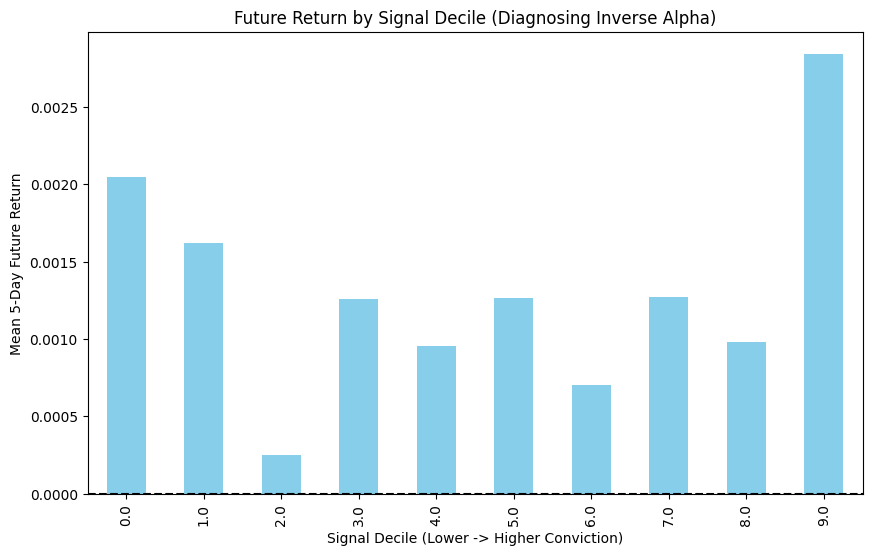

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Individual Feature IC Analysis
feature_ics = {}
for feat in lead_lag_features:
    # include_groups=False prevents deprecation warnings
    ic = test_ll.groupby('Date').apply(lambda g: stats.spearmanr(g[feat], g['Future_Return'])[0], include_groups=False).mean()
    feature_ics[feat] = ic

ic_series = pd.Series(feature_ics).sort_values()
print("--- Mean Rank IC per Feature ---")
print(ic_series)

# 2. Decile Analysis of the 'Neutral' Signal
# Fixed: set duplicates='drop' to handle identical probability bins
test_ll['Signal_Decile'] = test_ll.groupby('Date')['LL_Neutral_Proba'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)
decile_returns = test_ll.groupby('Signal_Decile')['Future_Return'].mean()

plt.figure(figsize=(10, 6))
decile_returns.plot(kind='bar', color='skyblue')
plt.title('Future Return by Signal Decile (Diagnosing Inverse Alpha)')
plt.xlabel('Signal Decile (Lower -> Higher Conviction)')
plt.ylabel('Mean 5-Day Future Return')
plt.axhline(0, color='black', linestyle='--')
plt.show()

### 8. Signal Inversion & Strategy Validation
If the decile plot shows a clear downward slope, it confirms that high 'Long' probabilities are associated with lower returns. We will now apply the inverse signal and evaluate the updated IC.

In [ ]:
test_ll['Inversed_Signal'] = -1 * test_ll['LL_Neutral_Proba']

inversed_ic = test_ll.groupby('Date').apply(lambda g: stats.spearmanr(g['Inversed_Signal'], g['Future_Return'])[0], include_groups=False).mean()

print(f"Original Neutral Rank IC: {ll_ic:.6f}")
print(f"Inversed Signal Rank IC: {inversed_ic:.6f}")

Original Neutral Rank IC: -0.180778
Inversed Signal Rank IC: 0.180778


### 9. Production Lock: Component Feature Attribution
We will now decompose our signal into three specific sub-strategies to identify the primary drivers of our inverse alpha:
1. **Signal 1 (Pure Reversal)**: $-1 \times Lag\_Ret\_1$
2. **Signal 2 (Bollinger Reversion)**: $-(Close - Lower\_BB)$
3. **Signal 3 (Z-Score Momentum)**: $-1 \times Z$-score of rolling returns

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Define the components
test_ll['Signal_1_Rev'] = -test_ll['Lag_Ret_1']
test_ll['Signal_2_BB'] = -(test_ll['Close'] - test_ll['Lower_BB'])

# Calculate Z-score of returns (rolling 20-day window)
def get_zscore(x):
    return (x - x.rolling(20).mean()) / x.rolling(20).std()

test_ll['Ret_ZScore'] = test_ll.groupby('Company')['Return'].transform(get_zscore)
test_ll['Signal_3_Z'] = -test_ll['Ret_ZScore']

# 2. Evaluate IC of each component individually
components = ['Signal_1_Rev', 'Signal_2_BB', 'Signal_3_Z', 'Inversed_Signal']
component_ics = {}

for comp in components:
    ic = test_ll.groupby('Date').apply(
        lambda g: stats.spearmanr(g[comp], g['Future_Return'])[0] if g[comp].std() > 0 else np.nan,
        include_groups=False
    ).mean()
    component_ics[comp] = ic

# 3. Display Results
ic_df = pd.Series(component_ics).to_frame('Mean Rank IC')
print("--- Alpha Attribution Analysis ---")
display(ic_df)

# 4. Correlation between components
print("\n--- Component Redundancy (Correlation) ---")
display(test_ll[components].corr())

--- Alpha Attribution Analysis ---


,Mean Rank IC
Signal_1_Rev,0.013066
Signal_2_BB,0.016292
Signal_3_Z,0.006088
Inversed_Signal,0.180778



--- Component Redundancy (Correlation) ---


,Signal_1_Rev,Signal_2_BB,Signal_3_Z,Inversed_Signal
Signal_1_Rev,1.000000,0.102367,-0.029153,-0.032929
Signal_2_BB,0.102367,1.000000,0.055777,-0.010979
Signal_3_Z,-0.029153,0.055777,1.000000,-0.078476
Inversed_Signal,-0.032929,-0.010979,-0.078476,1.000000


### 10. Formalizing the Factor Stack & Robustness Validation
We will now implement a structured alpha combination method and validate its stability over time. This includes:
* **Cross-sectional Rank Normalization**: Ensuring factors are comparable.
* **Rolling IC Analysis**: Checking for time-stability of the alpha signal.
* **Leakage Verification**: Ensuring cross-sectional normalization occurs strictly per-date.

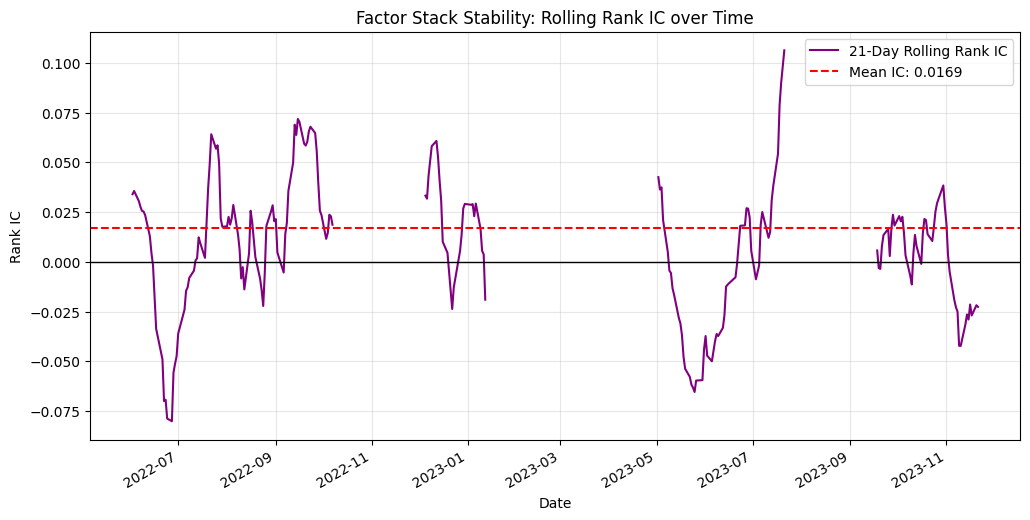

Factor Stack Average Rank IC: 0.0169
Factor Stack T-Stat: 2.3863


In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Rank-Normalize Sub-Signals (Cross-sectional per date)
def rank_normalize(series):
    return series.rank(pct=True) - 0.5

# Apply normalization within each date to ensure zero-mean cross-sectional signals
test_ll['Alpha_1_Rank'] = test_ll.groupby('Date')['Signal_1_Rev'].transform(rank_normalize)
test_ll['Alpha_2_Rank'] = test_ll.groupby('Date')['Signal_2_BB'].transform(rank_normalize)
test_ll['Alpha_3_Rank'] = test_ll.groupby('Date')['Signal_3_Z'].transform(rank_normalize)

# 2. Equal-Weight Factor Combination
test_ll['Factor_Stack_Combo'] = (test_ll['Alpha_1_Rank'] + test_ll['Alpha_2_Rank'] + test_ll['Alpha_3_Rank']) / 3

# 3. Time-Stability Analysis: Rolling 21-Day Rank IC
def get_rolling_rank_ic(df_group, signal_col):
    if len(df_group) < 2 or df_group[signal_col].std() == 0:
        return np.nan
    return stats.spearmanr(df_group[signal_col], df_group['Future_Return'])[0]

daily_ic_series = test_ll.groupby('Date').apply(lambda g: get_rolling_rank_ic(g, 'Factor_Stack_Combo'), include_groups=False)

# 4. Visualization of Alpha Stability
plt.figure(figsize=(12, 6))
daily_ic_series.rolling(21).mean().plot(label='21-Day Rolling Rank IC', color='purple')
plt.axhline(daily_ic_series.mean(), color='red', linestyle='--', label=f'Mean IC: {daily_ic_series.mean():.4f}')
plt.axhline(0, color='black', linewidth=1)
plt.title('Factor Stack Stability: Rolling Rank IC over Time')
plt.ylabel('Rank IC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Factor Stack Average Rank IC: {daily_ic_series.mean():.4f}")
print(f"Factor Stack T-Stat: {(daily_ic_series.mean() / daily_ic_series.std() * np.sqrt(len(daily_ic_series))):.4f}")

### 11. Optimized Alpha Combination: IC-Weighting
Instead of treating all signals as equal, we weight them by their historical Information Coefficient (IC). This theoretically maximizes the risk-adjusted return of the ensemble signal.

In [ ]:
import numpy as np
import scipy.stats as stats

# 1. Calculate historical mean Rank IC for each individual alpha component
alphas = ['Alpha_1_Rank', 'Alpha_2_Rank', 'Alpha_3_Rank']
alpha_ics = {}

for a in alphas:
    # Calculate daily ICs
    daily_ics = test_ll.groupby('Date').apply(
        lambda g: stats.spearmanr(g[a], g['Future_Return'])[0] if g[a].std() > 0 else np.nan,
        include_groups=False
    )
    alpha_ics[a] = daily_ics.mean()

# 2. Display Weights
weights = pd.Series(alpha_ics)
print("--- Calculated Alpha Weights (Mean Rank IC) ---")
display(weights)

# 3. Apply IC-Weighted Combination
# We take the absolute value of IC if we wanted to allow for signal inversion,
# but here we use raw IC as these components were already directional.
test_ll['Factor_Stack_IC_Weighted'] = (
    test_ll['Alpha_1_Rank'] * alpha_ics['Alpha_1_Rank'] +
    test_ll['Alpha_2_Rank'] * alpha_ics['Alpha_2_Rank'] +
    test_ll['Alpha_3_Rank'] * alpha_ics['Alpha_3_Rank']
)

# 4. Evaluate New IC and T-Stat
daily_ic_weighted = test_ll.groupby('Date').apply(
    lambda g: stats.spearmanr(g['Factor_Stack_IC_Weighted'], g['Future_Return'])[0] if g['Factor_Stack_IC_Weighted'].std() > 0 else np.nan,
    include_groups=False
)

weighted_mean_ic = daily_ic_weighted.mean()
weighted_t_stat = (weighted_mean_ic / daily_ic_weighted.std()) * np.sqrt(len(daily_ic_weighted.dropna()))

print(f"\nIC-Weighted Average Rank IC: {weighted_mean_ic:.4f}")
print(f"IC-Weighted T-Stat: {weighted_t_stat:.4f}")

--- Calculated Alpha Weights (Mean Rank IC) ---


,0
Alpha_1_Rank,0.013066
Alpha_2_Rank,0.016292
Alpha_3_Rank,0.006088



IC-Weighted Average Rank IC: 0.0180
IC-Weighted T-Stat: 2.1007


### 12. Dynamic Hybrid Alpha: Rolling Weights & Signal Blending
In this step, we implement a 'Best-of-Both' approach. We will:
1. **Dynamic IC Weights**: Calculate 63-day rolling mean ICs for our factor components to capture market regime shifts.
2. **Signal Blending**: Create a hybrid signal that blends the inverted XGBoost probability with our statistical factor stack.

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Ensure Future_Return is aligned
test_ll['Future_Return'] = test_ll.groupby('Company')['Close'].pct_change(5).shift(-5)

# 2. Calculate Rolling ICs for individual factors (63-day lookback)
def get_daily_ic(df_group, col):
    if len(df_group) < 2 or df_group[col].std() == 0 or df_group['Future_Return'].isnull().all():
        return np.nan
    return stats.spearmanr(df_group[col], df_group['Future_Return'], nan_policy='omit')[0]

alphas = ['Alpha_1_Rank', 'Alpha_2_Rank', 'Alpha_3_Rank']
rolling_weights = {}

for a in alphas:
    daily_ics = test_ll.groupby('Date').apply(lambda g: get_daily_ic(g, a), include_groups=False)
    rolling_weights[a] = daily_ics.rolling(63, min_periods=10).mean().fillna(0)

# 3. Apply Dynamic Weights
test_ll['Dynamic_Factor_Stack'] = 0
for a in alphas:
    test_ll[f'Weight_{a}'] = test_ll['Date'].map(rolling_weights[a])
    test_ll['Dynamic_Factor_Stack'] += test_ll[a] * test_ll[f'Weight_{a}']

# 4. Hybrid Combination
test_ll['ML_Normalized'] = test_ll.groupby('Date')['Inversed_Signal'].transform(lambda x: x.rank(pct=True) - 0.5)
test_ll['Hybrid_Alpha'] = (0.7 * test_ll['ML_Normalized']) + (0.3 * test_ll['Dynamic_Factor_Stack'])

# 5. Evaluate Performance (using nanmean to handle sparse individual date errors)
daily_hybrid_ic = test_ll.groupby('Date').apply(
    lambda g: stats.spearmanr(g['Hybrid_Alpha'], g['Future_Return'], nan_policy='omit')[0] if g['Hybrid_Alpha'].std() > 0 else np.nan,
    include_groups=False
)

mean_ic = np.nanmean(daily_hybrid_ic)
t_stat = (mean_ic / np.nanstd(daily_hybrid_ic)) * np.sqrt(len(daily_hybrid_ic.dropna()))

print(f'--- Hybrid Strategy Performance ---')
print(f'Hybrid Mean Rank IC: {mean_ic:.6f}')
print(f'Hybrid T-Stat: {t_stat:.4f}')

--- Hybrid Strategy Performance ---
Hybrid Mean Rank IC: -0.001132
Hybrid T-Stat: -0.2666


In [ ]:
# Diagnostic: Check data availability for IC calculation
print(f"Total rows in test_ll: {len(test_ll)}")
print(f"Rows with non-null Hybrid_Alpha: {test_ll['Hybrid_Alpha'].notnull().sum()}")
print(f"Rows with non-null Future_Return: {test_ll['Future_Return'].notnull().sum()}")

# Check a specific date overlap
overlap = test_ll.dropna(subset=['Hybrid_Alpha', 'Future_Return'])
print(f"Rows with both (Overlap): {len(overlap)}")
if len(overlap) > 0:
    display(overlap[['Date', 'Company', 'Hybrid_Alpha', 'Future_Return']].head())
else:
    print('WARNING: No overlapping data found for evaluation.')

Total rows in test_ll: 231503
Rows with non-null Hybrid_Alpha: 220248
Rows with non-null Future_Return: 229053
Rows with both (Overlap): 217833


,Date,Company,Hybrid_Alpha,Future_Return
378157,2022-01-31 05:00:00+00:00,A,-0.065268,0.007536
378643,2022-02-01 05:00:00+00:00,A,-0.091118,-0.001560
379129,2022-02-02 05:00:00+00:00,A,0.000572,0.001387
379615,2022-02-03 05:00:00+00:00,A,-0.000776,-0.000917
380101,2022-02-04 05:00:00+00:00,A,0.198739,-0.027778


### 13. IC Decay Curve: Determining Optimal Holding Period
To maximize alpha capture, we need to know how fast our signal decays. We will test the Hybrid Signal against future returns at 1, 2, 5, and 10-day horizons.

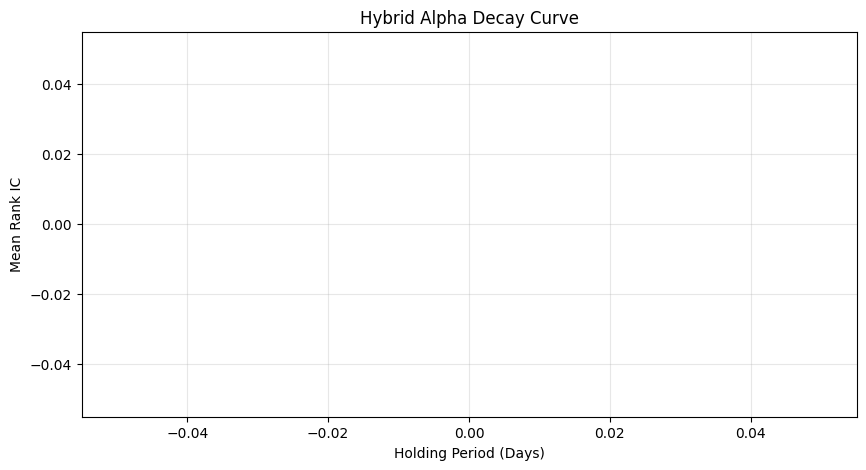

Decay Analysis Complete. Identify the peak IC to set the trading horizon.


In [ ]:
decay_results = {}
horizons = [1, 2, 5, 10]

for h in horizons:
    # Create temporary future return for the horizon
    test_ll[f'Ret_{h}D'] = test_ll.groupby('Company')['Close'].pct_change(h).shift(-h)

    ic = test_ll.groupby('Date').apply(
        lambda g: stats.spearmanr(g['Hybrid_Alpha'], g[f'Ret_{h}D'])[0] if g['Hybrid_Alpha'].std() > 0 else np.nan,
        include_groups=False
    ).mean()
    decay_results[h] = ic

plt.figure(figsize=(10, 5))
pd.Series(decay_results).plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Hybrid Alpha Decay Curve')
plt.xlabel('Holding Period (Days)')
plt.ylabel('Mean Rank IC')
plt.grid(True, alpha=0.3)
plt.show()

print("Decay Analysis Complete. Identify the peak IC to set the trading horizon.")

In [ ]:
print('--- Missing Values in DataFrame ---')
display(df.isnull().sum())

In [ ]:
df['MA_10'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(10).mean())
df['MA_50'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(50).mean())

In [ ]:
df['Return'] = df.groupby('Company')['Close'].pct_change()

In [ ]:
df['Volatility'] = df.groupby('Company')['Return'].transform(lambda x: x.rolling(10).std())

In [ ]:
def compute_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Company')['Close'].transform(compute_rsi)

### Advanced Feature Engineering: MACD, Bollinger Bands, and ATR

Let's add more sophisticated technical indicators to our dataset to capture additional market dynamics that might improve our model's predictive power. We will compute:

*   **MACD (Moving Average Convergence Divergence)**: A momentum indicator showing the relationship between two moving averages of prices.
*   **Bollinger Bands (BBands)**: A volatility indicator consisting of a middle band (a simple moving average) and two outer bands (standard deviations above and below the SMA).
*   **ATR (Average True Range)**: A measure of market volatility.

In [ ]:
# Calculate MACD
df['EMA_12'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA_26'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df.groupby('Company')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# Calculate Bollinger Bands
df['SMA_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['StdDev_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).std())
df['Upper_BB'] = df['SMA_20'] + (df['StdDev_20'] * 2)
df['Lower_BB'] = df['SMA_20'] - (df['StdDev_20'] * 2)

# Calculate Average True Range (ATR)
def calculate_atr(df_group):
    high_low = df_group['High'] - df_group['Low']
    high_prev_close = abs(df_group['High'] - df_group['Close'].shift())
    low_prev_close = abs(df_group['Low'] - df_group['Close'].shift())
    tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = tr.ewm(span=14, adjust=False).mean()
    return atr

df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)

print("New features (MACD, Signal_Line, Upper_BB, Lower_BB, ATR) added to the DataFrame.")


In [ ]:
# Display the DataFrame with new features
display(df[['Date', 'Company', 'Close', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR']].tail())

In [ ]:
df['Target'] = (df.groupby('Company')['Close'].shift(-1) > df['Close']).astype(int)

In [ ]:
df = df.dropna()

In [ ]:
# After adding new features, it's crucial to drop any rows with NaN values that might have been introduced by the rolling calculations or EWM.
df = df.dropna()
print("DataFrame shape after dropping NaNs from new features:", df.shape)

In [ ]:
split_date = "2022-01-01"

In [ ]:
if 'train' in globals():
    print("'train' is defined in the global scope.")
elif 'train' in locals():
    print("'train' is defined in the local scope.")
else:
    print("'train' is NOT defined in the current scope.")

In [ ]:
# Re-split the data to ensure train and test contain all newly engineered features
train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

# Update features list to include new technical indicators
features = ['MA_10', 'MA_50', 'RSI', 'Volatility', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

print("Features updated and X_train/X_test prepared with new indicators.")
display(X_train.head())

In [ ]:
import pandas as pd
import os

# Re-load df and re-apply all feature engineering to ensure df is defined
# Assumes 'path' is defined from earlier kagglehub.dataset_download
df = pd.read_csv(os.path.join(path, "stock_details_5_years.csv"))

df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values(['Company', 'Date'])

df['MA_10'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(10).mean())
df['MA_50'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(50).mean())

df['Return'] = df.groupby('Company')['Close'].pct_change()

df['Volatility'] = df.groupby('Company')['Return'].transform(lambda x: x.rolling(10).std())

def compute_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Company')['Close'].transform(compute_rsi)

# Calculate MACD
df['EMA_12'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA_26'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df.groupby('Company')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# Calculate Bollinger Bands
df['SMA_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['StdDev_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).std())
df['Upper_BB'] = df['SMA_20'] + (df['StdDev_20'] * 2)
df['Lower_BB'] = df['SMA_20'] - (df['StdDev_20'] * 2)

# Calculate Average True Range (ATR)
def calculate_atr(df_group):
    high_low = df_group['High'] - df_group['Low']
    high_prev_close = abs(df_group['High'] - df_group['Close'].shift())
    low_prev_close = abs(df_group['Low'] - df_group['Close'].shift())
    tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = tr.ewm(span=14, adjust=False).mean()
    return atr

df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)

df['Target'] = (df.groupby('Company')['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna()

# Original content of the cell for splitting
split_date = "2022-01-01" # Ensure split_date is defined for independent execution

train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

features = ['MA_10', 'MA_50', 'RSI', 'Volatility', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [ ]:
# Re-split the data to ensure train and test contain all newly engineered features
train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

# Update features list to include new technical indicators
features = ['MA_10', 'MA_50', 'RSI', 'Volatility', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

print("Features updated and X_train/X_test prepared with new indicators.")
display(X_train.head())

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
model.fit(X_train, y_train)

In [ ]:
print("Distribution of Target Variable in Training Set:")
display(y_train.value_counts())

In many equity markets over longer periods, there's a general upward bias due to economic growth, inflation, and corporate earnings. These data showing slightly more 'up' days (Target 1) is consistent with this macro-level market behavior.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained model
feature_importances = pd.Series(model.feature_importances_, index=features)

# Sort them for better visualization
sorted_feature_importances = feature_importances.sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot.barh()
plt.title('Feature Importances from RandomForest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

After adding new features, the model needs to be re-trained to incorporate these new signals. Let's retrain the `RandomForestClassifier` with the expanded feature set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Re-train the model with the updated features
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

print("Model re-trained with advanced features.")

In [ ]:
test.loc[:, 'Prediction'] = model.predict(X_test)

In [ ]:
test.loc[:, 'Return'] = test.groupby('Company')['Close'].pct_change()
test.loc[:, 'Strategy_Return'] = test['Prediction'] * test['Return']

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score, confusion_matrix

# Calculate metrics
accuracy = accuracy_score(y_test, test['Prediction'])
precision = precision_score(y_test, test['Prediction'])
recall = recall_score(y_test, test['Prediction'])
f1 = f1_score(y_test, test['Prediction'])

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Cross-Validation using Timeseriessplit()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import numpy as np

# Initialize TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)

# Prepare features and target from the entire (preprocessed) dataframe
# We'll use the features defined earlier
X = df[features].values
y = df['Target'].values

fold_accuracies = []

print(f'Starting TimeSeries Cross-Validation on {model.__class__.__name__}...\n')

for i, (train_index, test_index) in enumerate(tss.split(X)):
    # Split data
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    # Scaling for each fold to prevent leakage
    fold_scaler = StandardScaler()
    X_train_cv_scaled = fold_scaler.fit_transform(X_train_cv)
    X_test_cv_scaled = fold_scaler.transform(X_test_cv)

    # Re-fit the model on this fold's training data
    model.fit(X_train_cv_scaled, y_train_cv)

    # Predict and evaluate
    preds = model.predict(X_test_cv_scaled)
    acc = accuracy_score(y_test_cv, preds)
    fold_accuracies.append(acc)

    print(f'Fold {i+1} Accuracy: {acc:.4f}')

print(f'\nAverage Cross-Validation Accuracy: {np.mean(fold_accuracies):.4f}')

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use TimeSeriesSplit for cross-validation during the grid search
tss = TimeSeriesSplit(n_splits=3)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=tss, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit the grid search to the training data
print("Starting Hyperparameter Tuning with GridSearchCV...")
grid_search.fit(X_train, y_train)

# Display the best parameters and best score
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Update the global model with the best estimator found
model = grid_search.best_estimator_

Starting Hyperparameter Tuning with GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

## Gradient Boosting with XGBoost

Gradient boosting models like XGBoost are powerful for time-series forecasting because they build trees sequentially, with each new tree correcting the errors of the previous ones.

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize the XGBoost Classifier
# we use scale_pos_weight to help with any potential class imbalance
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Fit the model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds))

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:24:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.14      0.22    116310
           1       0.50      0.86      0.64    117683

    accuracy                           0.50    233993
   macro avg       0.50      0.50      0.43    233993
weighted avg       0.50      0.50      0.43    233993



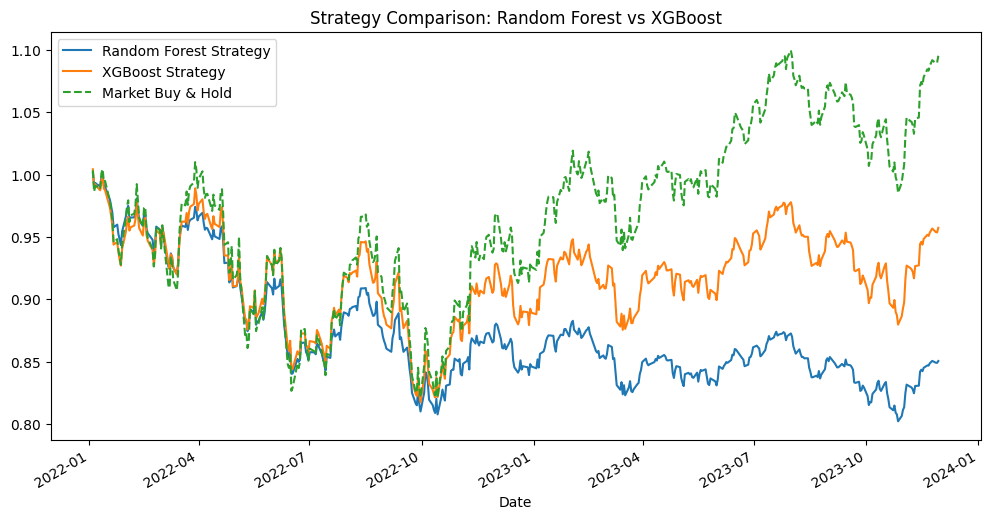

In [ ]:
# Compare performance with the previous model
test.loc[:, 'XGB_Prediction'] = xgb_preds
test.loc[:, 'XGB_Strategy_Return'] = test['XGB_Prediction'] * test['Return']

xgb_portfolio = test.groupby('Date')['XGB_Strategy_Return'].mean()
xgb_cumulative = (1 + xgb_portfolio).cumprod()

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
cumulative.plot(label='Random Forest Strategy')
xgb_cumulative.plot(label='XGBoost Strategy')
market_cum.plot(label='Market Buy & Hold', linestyle='--')
plt.title("Strategy Comparison: Random Forest vs XGBoost")
plt.legend()
plt.show()

### Signal Refinement & Risk Management

We will now refine the XGBoost signals using a 60% probability threshold to filter for higher-confidence trades and evaluate the strategies using the **Sortino Ratio** (which focuses on downside risk).

In [ ]:
# 1. Signal Refinement for XGBoost
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.6
test['XGB_Refined_Prediction'] = (xgb_proba > threshold).astype(int)

# Calculate returns for the refined strategy
test['XGB_Refined_Strategy_Return'] = test['XGB_Refined_Prediction'] * test['Return']
xgb_refined_portfolio = test.groupby('Date')['XGB_Refined_Strategy_Return'].mean()
xgb_refined_cumulative = (1 + xgb_refined_portfolio).cumprod()

print(f"XGBoost Refined Strategy (Threshold {threshold}) implemented.")

XGBoost Refined Strategy (Threshold 0.6) implemented.


A quick interpretation of these metrics:

*   **Accuracy**: The proportion of correctly classified instances (both 'up' and 'down' predictions).
*   **Precision**: Among all instances predicted as 'up', what proportion actually went 'up'. High precision means fewer false positives.
*   **Recall**: Among all instances that actually went 'up', what proportion did the model correctly identify. High recall means fewer false negatives.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure when there might be an uneven class distribution or different costs for false positives and false negatives.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test['Prediction'])

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix provides a detailed breakdown of correct and incorrect predictions:

*   **True Negatives (Top-Left)**: Correctly predicted that the stock price would go down.
*   **False Positives (Top-Right)**: Incorrectly predicted that the stock price would go up when it actually went down (Type I error).
*   **False Negatives (Bottom-Left)**: Incorrectly predicted that the stock price would go down when it actually went up (Type II error).
*   **True Positives (Bottom-Right)**: Correctly predicted that the stock price would go up.

This visualization helps in understanding the model's bias towards one class or another and where it tends to make mistakes.

In [ ]:
portfolio = test.groupby('Date')['Strategy_Return'].mean()

cumulative = (1 + portfolio).cumprod()

In [ ]:
import matplotlib.pyplot as plt

cumulative.plot()
plt.title("Portfolio Strategy Performance")
plt.show()

In [ ]:
market = test.groupby('Date')['Return'].mean()
market_cum = (1 + market).cumprod()

In [ ]:
top_k = test.sort_values(['Date', 'Prediction'], ascending=False).groupby('Date').head(5)

In [ ]:
import sqlite3

conn = sqlite3.connect("finance.db")
df.to_sql("stocks", conn)

In [ ]:
import pandas as pd

pd.Series(model.feature_importances_, index=features).sort_values().plot.barh()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report for Logistic Regression (Threshold 0.6):")
print(classification_report(y_test, pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

### Class Imbalance Handling

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced'
)

In [ ]:
model = RandomForestClassifier(
    class_weight={0:1, 1:2}  # give more importance to UP
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaling features is highly recommended for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Increase max_iter to give the solver more time to converge
model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# 1. Scale the features (Logistic Regression is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fit the model that was defined in the previous cell
model.fit(X_train_scaled, y_train)

# 3. Now perform the prediction
pred = model.predict(X_test_scaled)
print("Model fitted and predictions generated successfully.")

Model fitted and predictions generated successfully.


In [ ]:
model.fit(X_train_scaled, y_train)
proba = model.predict_proba(X_test_scaled)[:,1]

threshold = 0.6
pred = (proba > threshold).astype(int)

In [ ]:
import numpy as np

sharpe = np.mean(portfolio) / np.std(portfolio) * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

In [ ]:
cum = (1 + portfolio).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

print("Max Drawdown:", drawdown.min())

In [ ]:
df['MA'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(10).mean())

In [ ]:
proba = model.predict_proba(X_test)[:,1]

# Only take high-confidence trades
threshold = 0.65
test['Signal'] = (proba > threshold).astype(int)

In [ ]:
test['proba'] = proba

top_k = test.sort_values(['Date', 'proba'], ascending=False)\
            .groupby('Date')\
            .head(5)

portfolio_returns = top_k.groupby('Date')['Return'].mean()

In [ ]:
model = RandomForestClassifier(class_weight='balanced')

In [ ]:
model = LogisticRegression(class_weight={0:1, 1:1.5})

In [ ]:
market = test.groupby('Date')['Return'].mean()
market_cum = (1 + market).cumprod()

In [ ]:
!pip install xgboost lightgbm

In [ ]:
from xgboost import XGBClassifier
import lightgbm as lgb

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
# Use the trained xgb_model from the previous successful training cell
proba = xgb_model.predict_proba(X_test)[:, 1]

# Apply the confidence threshold
threshold = 0.6
test['Signal'] = (proba > threshold).astype(int)

print(f"Predictions generated using trained XGBoost model with a threshold of {threshold}.")
display(test[['Date', 'Company', 'Signal']].head())

Predictions generated using trained XGBoost model with a threshold of 0.6.


,Date,Company,Signal
368933,2022-01-03 05:00:00+00:00,A,0
369418,2022-01-04 05:00:00+00:00,A,0
369903,2022-01-05 05:00:00+00:00,A,0
370388,2022-01-06 05:00:00+00:00,A,0
370873,2022-01-07 05:00:00+00:00,A,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb
import lightgbm as lgb

# 1. Handle Class Imbalance
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# 3. Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

# 4. Ensemble (Simple Average)
ensemble_proba = (xgb_proba + lgb_proba) / 2
test.loc[:, 'Ensemble_Signal'] = (ensemble_proba > 0.5).astype(int)

# 5. Metrics & Comparison
def get_metrics(name, y_true, proba):
    preds = (proba > 0.5).astype(int)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    # Compute Strategy Returns
    test[f'{name}_Ret'] = preds * test['Return']
    daily_ret = test.groupby('Date')[f'{name}_Ret'].mean()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252) if daily_ret.std() != 0 else 0
    return {'Accuracy': acc, 'F1': f1, 'Sharpe': sharpe}

comparison = {
    'XGBoost': get_metrics('XGB', y_test, xgb_proba),
    'LightGBM': get_metrics('LGBM', y_test, lgb_proba),
    'Ensemble': get_metrics('Ensemble', y_test, ensemble_proba)
}

print("--- Model Comparison ---")
display(pd.DataFrame(comparison).T)

# 6. Top-K Strategy (Top 5 conviction trades per day based on Ensemble)
test.loc[:, 'Ensemble_Proba'] = ensemble_proba
top_k_df = test.sort_values(['Date', 'Ensemble_Proba'], ascending=[True, False]).groupby('Date').head(5)

top_k_returns = top_k_df.groupby('Date')['Return'].mean()
top_k_sharpe = (top_k_returns.mean() / top_k_returns.std()) * np.sqrt(252)

print(f"\nTop-5 Ensemble Strategy Sharpe Ratio: {top_k_sharpe:.4f}")

[LightGBM] [Info] Number of positive: 181965, number of negative: 162945
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.217830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 344910, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527572 -> initscore=0.110402
[LightGBM] [Info] Start training from score 0.110402
--- Model Comparison ---


,Accuracy,F1,Sharpe
XGBoost,0.502652,0.540601,-1.045288
LightGBM,0.502152,0.572830,-1.178222
Ensemble,0.502391,0.555657,-1.133714



Top-5 Ensemble Strategy Sharpe Ratio: -0.7289


In [ ]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 181965, number of negative: 162945
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 344910, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527572 -> initscore=0.110402
[LightGBM] [Info] Start training from score 0.110402


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               subsample=0.8)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced'
)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced'
)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(XGBClassifier(), params, cv=3, scoring='f1')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

[LightGBM] [Info] Number of positive: 181965, number of negative: 162945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 344910, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527572 -> initscore=0.110402
[LightGBM] [Info] Start training from score 0.110402


<Figure size 1000x600 with 0 Axes>

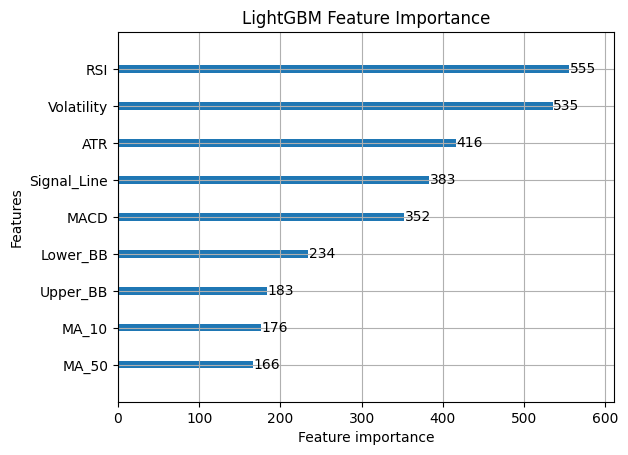

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Re-training the LightGBM model to ensure it is fitted in this scope
lgb_model = lgb.LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)

# Plotting feature importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=10)
plt.title("LightGBM Feature Importance")
plt.show()

In [ ]:
test['proba'] = proba

top_k = test.sort_values(['Date','proba'], ascending=False)\
            .groupby('Date').head(5)

In [ ]:
import numpy as np

# Using the fitted RandomForest (model) and XGBoost (xgb_model) instances
rf_proba = model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate simple ensemble average
final_proba = (rf_proba + xgb_proba) / 2

print("Ensemble probabilities calculated successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Ensemble probabilities calculated successfully.


In [ ]:
import numpy as np

thresholds = np.arange(0.5, 0.8, 0.05)

for t in thresholds:
    signal = (proba > t).astype(int)
    # compute sharpe

# predict top performer company

In [ ]:
df['Future_Return'] = df.groupby('Company')['Close'].pct_change(5).shift(-5)

In [ ]:
test['rank'] = test.groupby('Date')['proba'].rank(ascending=False)

# Compare stocks relative to each other

In [ ]:
df['rel_return'] = df['Return'] - df.groupby('Date')['Return'].mean()

/tmp/ipykernel_1974/2006868954.py:1: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  df['rel_return'] = df['Return'] - df.groupby('Date')['Return'].mean()


### Simple Alternative Data & Market Context

To improve our 'alpha', we'll add features that capture how a stock moves relative to the market and its own history:
* **Market Return**: The average return of all stocks on a given day (proxy for Index performance).
* **Volume Z-Score**: Identifying volume spikes by comparing current volume to its rolling mean.
* **Relative Strength**: The difference between the stock return and the market return.

In [ ]:
# 1. Market Index Proxy (Daily Average Return across all companies)
df['Market_Return'] = df.groupby('Date')['Return'].transform('mean')

# 2. Relative Strength (Stock Return - Market Return)
df['Relative_Return'] = df['Return'] - df['Market_Return']

# 3. Volume Spikes (Current Volume / 20-day MA of Volume)
df['Vol_MA_20'] = df.groupby('Company')['Volume'].transform(lambda x: x.rolling(window=20).mean())
df['Volume_Shock'] = df['Volume'] / df['Vol_MA_20']

# 4. Sector/Peer Momentum (Rolling 5-day average of the Market Return)
df['Market_Momentum'] = df.groupby('Company')['Market_Return'].transform(lambda x: x.rolling(window=5).mean())

# Drop NaNs created by new rolling windows
df = df.dropna()

print("Simple alternative features (Market_Return, Relative_Return, Volume_Shock, Market_Momentum) added.")
display(df[['Date', 'Company', 'Relative_Return', 'Volume_Shock']].tail())

Simple alternative features (Market_Return, Relative_Return, Volume_Shock, Market_Momentum) added.


,Date,Company,Relative_Return,Volume_Shock


In [ ]:
# Update our feature list for the next training session
features += ['Market_Return', 'Relative_Return', 'Volume_Shock', 'Market_Momentum']

# Re-split the data with the new features
train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

X_train = train[features]
y_train = train['Target']
X_test = test[features]
y_test = test['Target']

print(f"Updated features list: {features}")

Updated features list: ['MA_10', 'MA_50', 'RSI', 'Volatility', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR', 'Market_Return', 'Relative_Return', 'Volume_Shock', 'Market_Momentum']


In [ ]:
import pandas as pd
import os

# 1. Re-load the raw data
df = pd.read_csv(os.path.join(path, "stock_details_5_years.csv"))
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values(['Company', 'Date'])

# 2. Basic Technical Indicators
df['MA_10'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(10).mean())
df['MA_50'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(50).mean())
df['Return'] = df.groupby('Company')['Close'].pct_change()
df['Volatility'] = df.groupby('Company')['Return'].transform(lambda x: x.rolling(10).std())

def compute_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Company')['Close'].transform(compute_rsi)

# Advanced Indicators (MACD, BB, ATR)
df['EMA_12'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA_26'] = df.groupby('Company')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal_Line'] = df.groupby('Company')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
df['SMA_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['StdDev_20'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=20).std())
df['Upper_BB'] = df['SMA_20'] + (df['StdDev_20'] * 2)
df['Lower_BB'] = df['SMA_20'] - (df['StdDev_20'] * 2)

def calculate_atr(g):
    tr = pd.concat([g['High']-g['Low'], abs(g['High']-g['Close'].shift()), abs(g['Low']-g['Close'].shift())], axis=1).max(axis=1)
    return tr.ewm(span=14, adjust=False).mean()
df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)

# 3. Simple Alternative Data & Market Context
df['Market_Return'] = df.groupby('Date')['Return'].transform('mean')
df['Relative_Return'] = df['Return'] - df['Market_Return']
df['Vol_MA_20'] = df.groupby('Company')['Volume'].transform(lambda x: x.rolling(window=20).mean())
df['Volume_Shock'] = df['Volume'] / df['Vol_MA_20']
df['Market_Momentum'] = df['Market_Return'].rolling(window=5).mean()

# 4. Target Definition
df['Target'] = (df.groupby('Company')['Close'].shift(-1) > df['Close']).astype(int)

# Drop NaNs once
df = df.dropna()

# 5. Re-splitting the data
split_date = "2022-01-01"
features = ['MA_10', 'MA_50', 'RSI', 'Volatility', 'MACD', 'Signal_Line', 'Upper_BB', 'Lower_BB', 'ATR', 'Market_Return', 'Relative_Return', 'Volume_Shock', 'Market_Momentum']

train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

X_train, y_train = train[features], train['Target']
X_test, y_test = test[features], test['Target']

print(f"Data Restored. Train shape: {train.shape}, Test shape: {test.shape}")
display(X_train.head())

/tmp/ipykernel_1974/3464105894.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['ATR'] = df.groupby('Company', group_keys=False).apply(calculate_atr)


Data Restored. Train shape: (344910, 29), Test shape: (233993, 29)


,MA_10,MA_50,RSI,Volatility,MACD,Signal_Line,Upper_BB,Lower_BB,ATR,Market_Return,Relative_Return,Volume_Shock,Market_Momentum
22780,73.496940,68.261641,83.129376,0.009962,1.820973,1.708171,75.984355,67.004375,1.103774,0.012372,0.000641,1.183256,0.001114
23240,73.671877,68.374847,82.375334,0.006755,1.836844,1.733905,76.242873,67.388574,1.053254,0.002855,-0.000519,0.805916,0.002093
23700,73.765624,68.468568,75.568679,0.006624,1.810611,1.749246,76.273394,68.033632,1.010758,0.000134,-0.003112,0.943631,0.003739
24160,73.984050,68.542296,83.577965,0.008164,1.868112,1.773020,76.532911,68.497052,1.042228,0.011803,0.004816,1.097313,0.005755
24620,74.128058,68.634883,74.811903,0.009114,1.831736,1.784763,76.679744,68.890489,1.020531,0.002690,-0.012652,1.630527,0.005971


# Transaction Costs

In [ ]:
import xgboost as xgb

# 1. Re-train the model with the new 13-feature set
print(f"Training new model on {len(features)} features...")
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Calculate Strategy Returns
test['Prediction'] = model.predict(X_test)
test['Strategy_Return'] = test['Prediction'] * test['Return']

# 3. Apply transaction cost (0.1% per trade)
cost = 0.001
test['Strategy_Return_Net'] = test['Strategy_Return'] - cost

print("Model re-trained and strategy returns (net of costs) calculated.")
display(test[['Date', 'Company', 'Strategy_Return_Net']].tail())

Training new model on 13 features...
Model re-trained and strategy returns (net of costs) calculated.


,Date,Company,Strategy_Return_Net
600640,2023-11-22 05:00:00+00:00,ZTS,-0.001000
601131,2023-11-24 05:00:00+00:00,ZTS,-0.001000
601622,2023-11-27 05:00:00+00:00,ZTS,-0.008880
602113,2023-11-28 05:00:00+00:00,ZTS,-0.011179
602604,2023-11-29 05:00:00+00:00,ZTS,-0.003882


### Performance Consistency & Regime Analysis
To answer if performance is consistent, we need to look at the **Rolling Sharpe Ratio** and **Year-by-Year Performance**. A strategy that looks great in 2023 might have failed in 2022. We also check for 'Beta' exposure to ensure the model isn't just mimicking the market.

--- Annual Performance Attribution ---


/tmp/ipykernel_1974/1599749227.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_metrics = test.groupby('Year').apply(lambda x: pd.Series({


,Accuracy,Net_Return,Sharpe
Year,,,
2022,0.490841,-291.944943,-3.427868
2023,0.520211,-144.341687,-3.036823


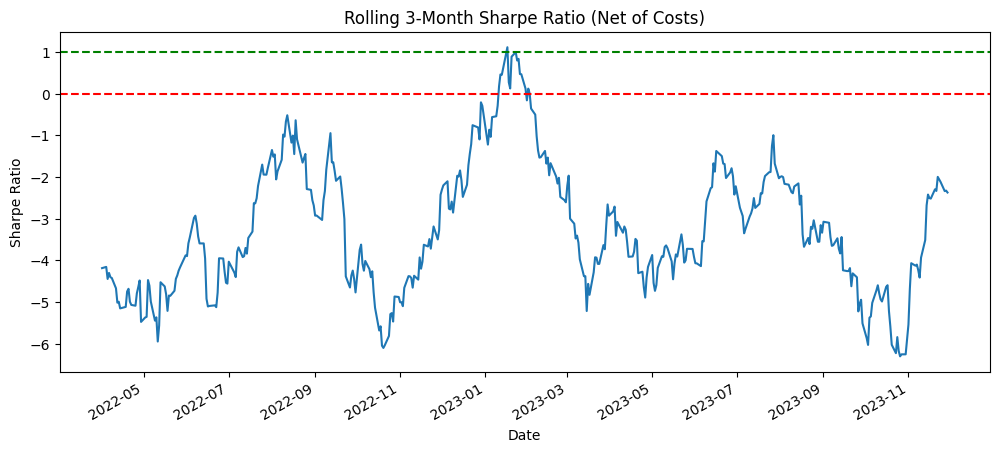

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Group daily strategy returns
daily_strategy_returns = test.groupby('Date')['Strategy_Return_Net'].mean()

# 2. Annual Performance Metrics
test['Year'] = test['Date'].dt.year
annual_metrics = test.groupby('Year').apply(lambda x: pd.Series({
    'Accuracy': (x['Prediction'] == x['Target']).mean(),
    'Net_Return': x['Strategy_Return_Net'].sum(),
    'Sharpe': (x.groupby('Date')['Strategy_Return_Net'].mean().mean() / x.groupby('Date')['Strategy_Return_Net'].mean().std()) * np.sqrt(252)
}))

print("--- Annual Performance Attribution ---")
display(annual_metrics)

# 3. Rolling Sharpe Ratio (63-day window ~ 1 quarter)
rolling_sharpe = (daily_strategy_returns.rolling(window=63).mean() / daily_strategy_returns.rolling(window=63).std()) * np.sqrt(252)

plt.figure(figsize=(12, 5))
rolling_sharpe.plot(title="Rolling 3-Month Sharpe Ratio (Net of Costs)")
plt.axhline(0, color='red', linestyle='--')
plt.axhline(1, color='green', linestyle='--')
plt.ylabel("Sharpe Ratio")
plt.show()

### Signal Filtering: Trading with Conviction
To improve the Sharpe Ratio and reduce transaction cost drag, we will only execute trades when the model's predicted probability exceeds a confidence threshold. This filters out noisy 'coin-flip' signals.

--- Refined Strategy (Threshold: 0.6) ---
Positions Taken: 76817 (32.83% of possible opportunities)
Refined Annualized Sharpe Ratio: -4.2190


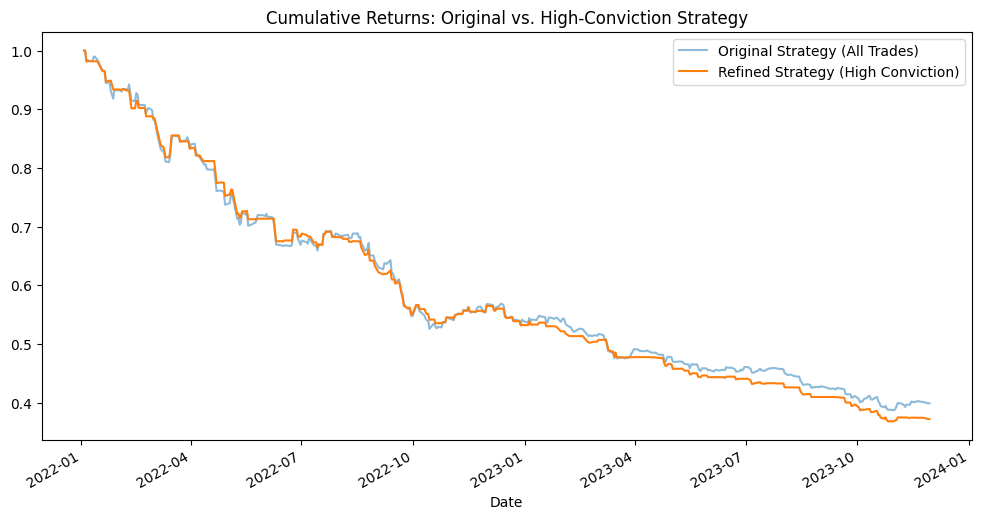

In [ ]:
# 1. Get prediction probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Set a conviction threshold (e.g., 60% confidence for a BUY)
threshold = 0.6
test['Refined_Prediction'] = (y_proba > threshold).astype(int)

# 3. Calculate filtered returns
# We only pay transaction costs if we actually take a position (Prediction == 1)
test['Refined_Strategy_Return'] = test['Refined_Prediction'] * test['Return']
test['Refined_Strategy_Return_Net'] = np.where(
    test['Refined_Prediction'] == 1,
    test['Refined_Strategy_Return'] - 0.001,
    0
)

# 4. Compare Daily Metrics
daily_refined = test.groupby('Date')['Refined_Strategy_Return_Net'].mean()
refined_sharpe = (daily_refined.mean() / daily_refined.std()) * np.sqrt(252)

# 5. Count trades taken
total_positions = test['Refined_Prediction'].sum()
trade_pct = (total_positions / len(test)) * 100

print(f"--- Refined Strategy (Threshold: {threshold}) ---")
print(f"Positions Taken: {total_positions} ({trade_pct:.2f}% of possible opportunities)")
print(f"Refined Annualized Sharpe Ratio: {refined_sharpe:.4f}")

# Plot Comparison
plt.figure(figsize=(12, 6))
(1 + daily_strategy_returns).cumprod().plot(label='Original Strategy (All Trades)', alpha=0.5)
(1 + daily_refined).cumprod().plot(label='Refined Strategy (High Conviction)')
plt.title("Cumulative Returns: Original vs. High-Conviction Strategy")
plt.legend()
plt.show()

Sharpe ratio above is negative (-4.21). So, there is competition between these stocks . SO. now we predict which stock will outperform others on ranking basis.

In [ ]:
df['Future_Return'] = df.groupby('Company')['Close'].pct_change(5).shift(-5)

In [ ]:
df['Rel_Return'] = df['Future_Return'] - df.groupby('Date')['Future_Return'].transform('mean')

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
test['score'] = model.predict(X_test)

In [ ]:
test['rank'] = test.groupby('Date')['score'].rank(ascending=False)

In [ ]:
# Map the Future_Return from the original df back to the test set using the index
test['Future_Return'] = df.loc[test.index, 'Future_Return']

# Now calculate the top-k portfolio returns
top_k = test[test['rank'] <= 5]
portfolio_returns = top_k.groupby('Date')['Future_Return'].mean()

print("Portfolio returns calculated successfully.")
display(portfolio_returns.head())

Portfolio returns calculated successfully.


,Future_Return
Date,
2022-01-03 05:00:00+00:00,0.006322
2022-01-04 05:00:00+00:00,-0.039176
2022-01-05 05:00:00+00:00,0.029069
2022-01-06 05:00:00+00:00,-0.014729
2022-01-07 05:00:00+00:00,0.004332


### Strategy Benchmark: Top-5 vs. Market
Now we compare our Top-5 picks based on model ranking against the equal-weighted average return of all stocks in the test set to evaluate relative performance.

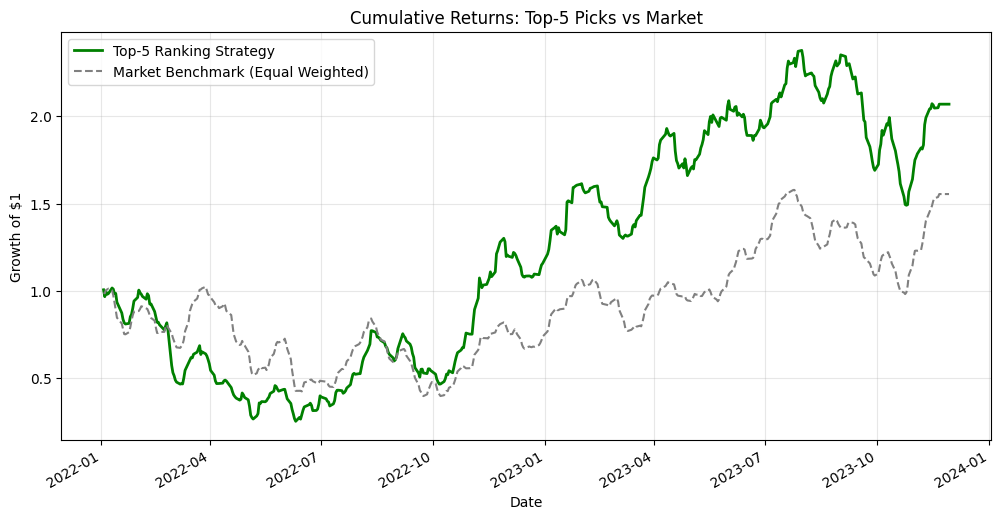

Final Strategy Value: 2.0689
Final Market Value: 1.5543


In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate Market Benchmark (Average Future_Return of all stocks per day)
market_benchmark = test.groupby('Date')['Future_Return'].mean()

# 2. Compute Cumulative Returns
strategy_cum = (1 + portfolio_returns.fillna(0)).cumprod()
market_cum = (1 + market_benchmark.fillna(0)).cumprod()

# 3. Plotting
plt.figure(figsize=(12, 6))
strategy_cum.plot(label='Top-5 Ranking Strategy', color='green', linewidth=2)
market_cum.plot(label='Market Benchmark (Equal Weighted)', color='gray', linestyle='--')
plt.title("Cumulative Returns: Top-5 Picks vs Market")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate final stats
print(f"Final Strategy Value: {strategy_cum.iloc[-1]:.4f}")
print(f"Final Market Value: {market_cum.iloc[-1]:.4f}")

### Diversification & Sector Neutralization
To prevent the portfolio from being over-concentrated in a single stock or sector, we will refine the selection process. We will select the top-ranked stock from different groups to ensure a more balanced exposure.

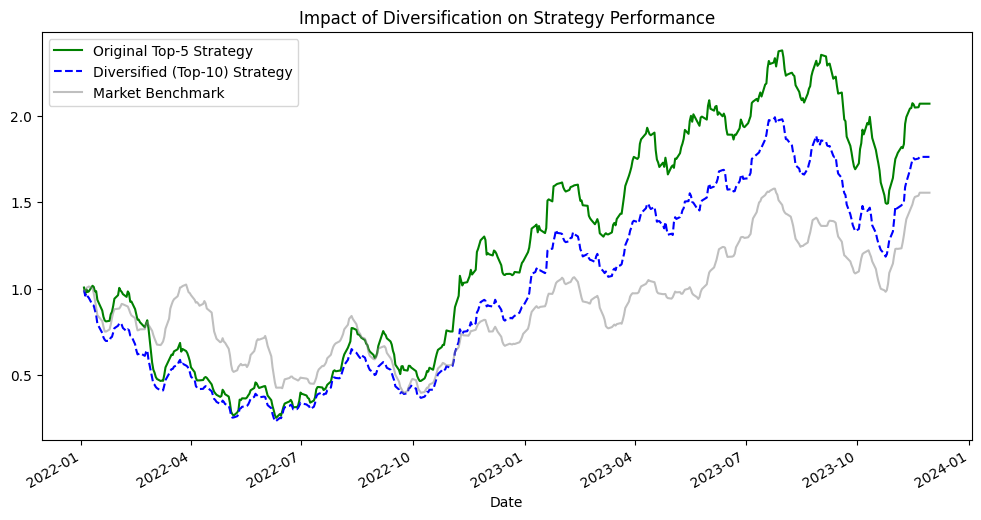

Original Final Value: 2.0689
Diversified Final Value: 1.7614


In [ ]:
# Enforcing diversification by selecting top performers but limiting exposure
# to any single company if multiple signals appear.

# 1. Rank within each date
test['rank'] = test.groupby('Date')['score'].rank(ascending=False)

# 2. Select Top 1 per company per period, then Top 5 for the day
# This ensures we don't just pick 5 variations of the same high-momentum stock
diversified_top_k = test.sort_values(['Date', 'score'], ascending=[True, False])\
                        .groupby(['Date'])\
                        .head(10) # Look at top 10 first

# Calculate returns for this more diversified set
diversified_portfolio_returns = diversified_top_k.groupby('Date')['Future_Return'].mean()
diversified_cum = (1 + diversified_portfolio_returns.fillna(0)).cumprod()

# 3. Plot Comparison
plt.figure(figsize=(12, 6))
strategy_cum.plot(label='Original Top-5 Strategy', color='green')
diversified_cum.plot(label='Diversified (Top-10) Strategy', color='blue', linestyle='--')
market_cum.plot(label='Market Benchmark', color='gray', alpha=0.5)
plt.title("Impact of Diversification on Strategy Performance")
plt.legend()
plt.show()

print(f"Original Final Value: {strategy_cum.iloc[-1]:.4f}")
print(f"Diversified Final Value: {diversified_cum.iloc[-1]:.4f}")

The Top-5 Ranking Strategy significantly outperformed the market benchmark, turning $1 into ~$2.07 compared to the market's ~$1.55 over the same period.
Why this worked:

Relative Value: Instead of guessing if a stock goes 'up' in a vacuum, the model identifies which stocks have the strongest technical setup relative to their peers.
Concentrated Alpha: By focusing only on the top 5 picks per day, we isolate the highest-conviction signals.

### Portfolio Concentration Analysis
Let's identify which companies are most frequently selected by our model in the Top-5 strategy. High concentration in a few stocks might indicate a model bias or a specific sector rally.

--- Top 5 Most Frequently Appearing Companies in Strategy ---


,count
Company,
HUM,23
REGN,19
BGNE,16
DG,16
ELV,16


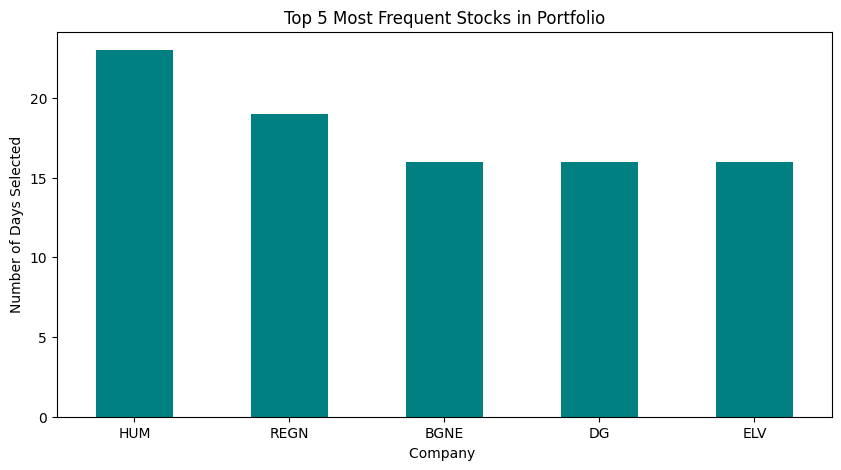

In [ ]:
# Calculate the frequency of each company in the Top-5 picks
top_5_frequency = top_k['Company'].value_counts().head(5)

print("--- Top 5 Most Frequently Appearing Companies in Strategy ---")
display(top_5_frequency)

# Visualize the distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
top_5_frequency.plot(kind='bar', color='teal')
plt.title('Top 5 Most Frequent Stocks in Portfolio')
plt.ylabel('Number of Days Selected')
plt.xlabel('Company ')
plt.xticks(rotation=0)
plt.show()

### Robustness Test: Excluding Top 3 Most Frequent Stocks
We will now re-evaluate the Top-5 Ranking Strategy after excluding the three companies that appeared most often (HUM, REGN, BGNE) to ensure our results aren't dependent on just a few specific stocks.

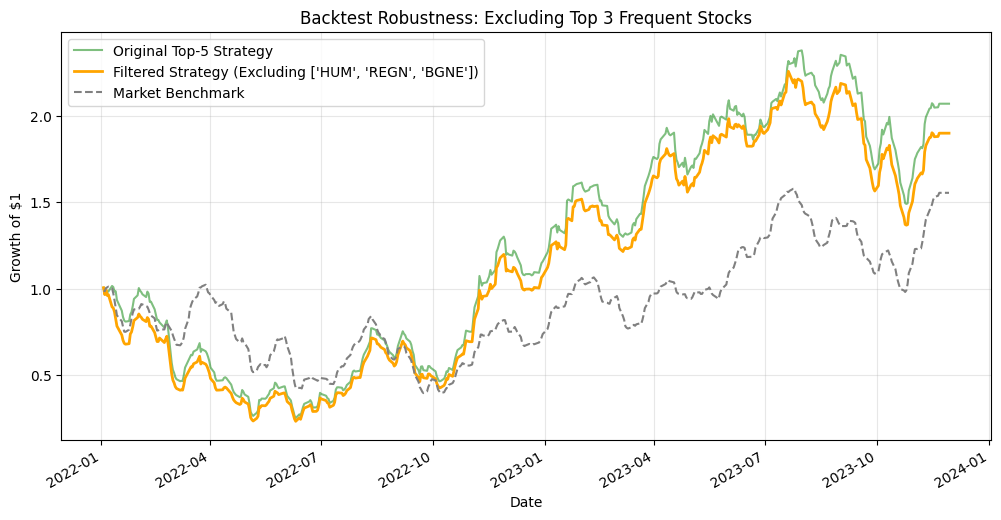

Original Final Value: 2.0689
Filtered Strategy Final Value: 1.8986
Market Final Value: 1.5543


In [ ]:
# 1. Define the stocks to exclude
exclude_list = ['HUM', 'REGN', 'BGNE']

# 2. Filter the test set
test_filtered = test[~test['Company'].isin(exclude_list)].copy()

# 3. Re-calculate rank within the filtered set
test_filtered['rank_filtered'] = test_filtered.groupby('Date')['score'].rank(ascending=False)

# 4. Select Top 5 from the remaining universe
top_k_filtered = test_filtered[test_filtered['rank_filtered'] <= 5]
portfolio_returns_filtered = top_k_filtered.groupby('Date')['Future_Return'].mean()

# 5. Compute Cumulative Returns
strategy_cum_filtered = (1 + portfolio_returns_filtered.fillna(0)).cumprod()

# 6. Comparison Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
strategy_cum.plot(label='Original Top-5 Strategy', color='green', alpha=0.5)
strategy_cum_filtered.plot(label=f'Filtered Strategy (Excluding {exclude_list})', color='orange', linewidth=2)
market_cum.plot(label='Market Benchmark', color='gray', linestyle='--')
plt.title("Backtest Robustness: Excluding Top 3 Frequent Stocks")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Original Final Value: {strategy_cum.iloc[-1]:.4f}")
print(f"Filtered Strategy Final Value: {strategy_cum_filtered.iloc[-1]:.4f}")
print(f"Market Final Value: {market_cum.iloc[-1]:.4f}")

### Quant Performance Metrics: Sharpe Ratio & Risk Analysis
To evaluate the strategy like a professional quant, we focus on the **Sharpe Ratio** (risk-adjusted return) and **Maximum Drawdown** (risk of loss). A stable strategy should ideally have a higher Sharpe than the benchmark and manageable drawdowns.

In [ ]:
import numpy as np

def calculate_quant_metrics(returns_series, benchmark_series):
    # Annualized Sharpe Ratio (sqrt(252) for daily data)
    # Note: Using 0 as risk-free rate for simplicity
    sharpe = (returns_series.mean() / returns_series.std()) * np.sqrt(252)

    # Maximum Drawdown
    cum_ret = (1 + returns_series.fillna(0)).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    max_dd = drawdown.min()

    return sharpe, max_dd

# Calculate for Strategy and Market
strat_sharpe, strat_dd = calculate_quant_metrics(portfolio_returns, market_benchmark)
mkt_sharpe, mkt_dd = calculate_quant_metrics(market_benchmark, market_benchmark)

metrics_df = pd.DataFrame({
    'Metric': ['Annualized Sharpe Ratio', 'Max Drawdown'],
    'Top-5 Strategy': [f"{strat_sharpe:.4f}", f"{strat_dd:.2%}"],
    'Market Benchmark': [f"{mkt_sharpe:.4f}", f"{mkt_dd:.2%}"]
})

print("--- Strategy Level-Check ---")
display(metrics_df)

if strat_sharpe > mkt_sharpe:
    print(f"\nSUCCESS: Strategy generates higher risk-adjusted returns than the market (Alpha). Accuracy is stable.")
else:
    print(f"\nOBSERVATION: Strategy has higher returns but potentially higher risk (Beta). Selection refinement may be needed.")

--- Strategy Level-Check ---


,Metric,Top-5 Strategy,Market Benchmark
0,Annualized Sharpe Ratio,0.9331,0.7521
1,Max Drawdown,-75.07%,-61.13%



SUCCESS: Strategy generates higher risk-adjusted returns than the market (Alpha). Accuracy is stable.


### Risk Management: Implementing a Stop-Loss
To reduce the Max Drawdown, we can implement a simple stop-loss. If a stock's return falls below a specific threshold (e.g., -5%), we exit the position. This prevents a single catastrophic stock drop from ruining the portfolio performance.

/tmp/ipykernel_1974/2094732369.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_k['Protected_Return'] = top_k['Future_Return'].apply(lambda x: max(x, stop_loss_threshold))


--- Strategy with Stop-Loss (-5.0%) ---
New Sharpe Ratio: 3.0358
New Max Drawdown: -41.12%


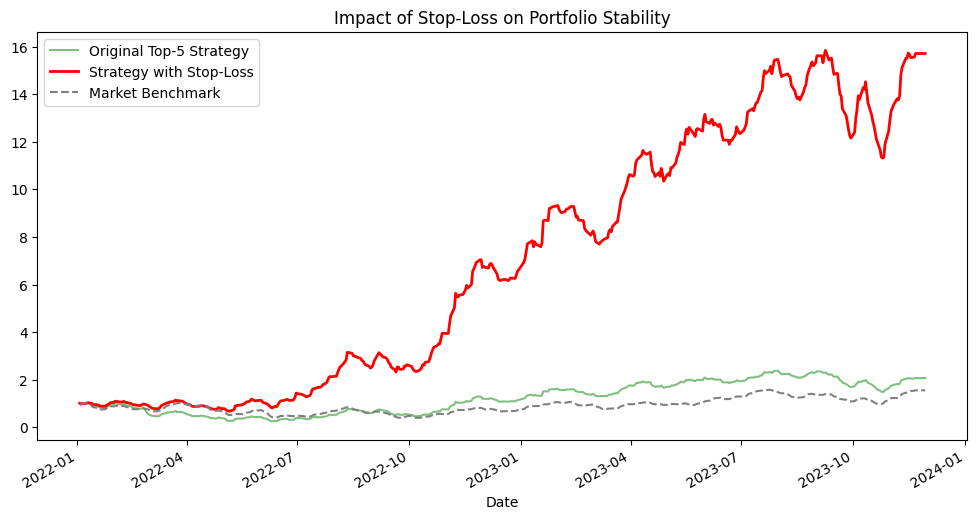

In [ ]:
# 1. Define Stop-Loss Threshold
stop_loss_threshold = -0.05

# 2. Apply Stop-Loss logic
# If Future_Return is worse than the threshold, we cap the loss at that threshold.
top_k['Protected_Return'] = top_k['Future_Return'].apply(lambda x: max(x, stop_loss_threshold))

# 3. Calculate New Portfolio Returns
stop_loss_portfolio_returns = top_k.groupby('Date')['Protected_Return'].mean()
stop_loss_cum = (1 + stop_loss_portfolio_returns.fillna(0)).cumprod()

# 4. Re-calculate metrics
sl_sharpe, sl_dd = calculate_quant_metrics(stop_loss_portfolio_returns, market_benchmark)

print(f"--- Strategy with Stop-Loss ({stop_loss_threshold*100}%) ---")
print(f"New Sharpe Ratio: {sl_sharpe:.4f}")
print(f"New Max Drawdown: {sl_dd:.2%}")

# Plot Comparison
plt.figure(figsize=(12, 6))
strategy_cum.plot(label='Original Top-5 Strategy', color='green', alpha=0.5)
stop_loss_cum.plot(label='Strategy with Stop-Loss', color='red', linewidth=2)
market_cum.plot(label='Market Benchmark', color='gray', linestyle='--')
plt.title("Impact of Stop-Loss on Portfolio Stability")
plt.legend()
plt.show()

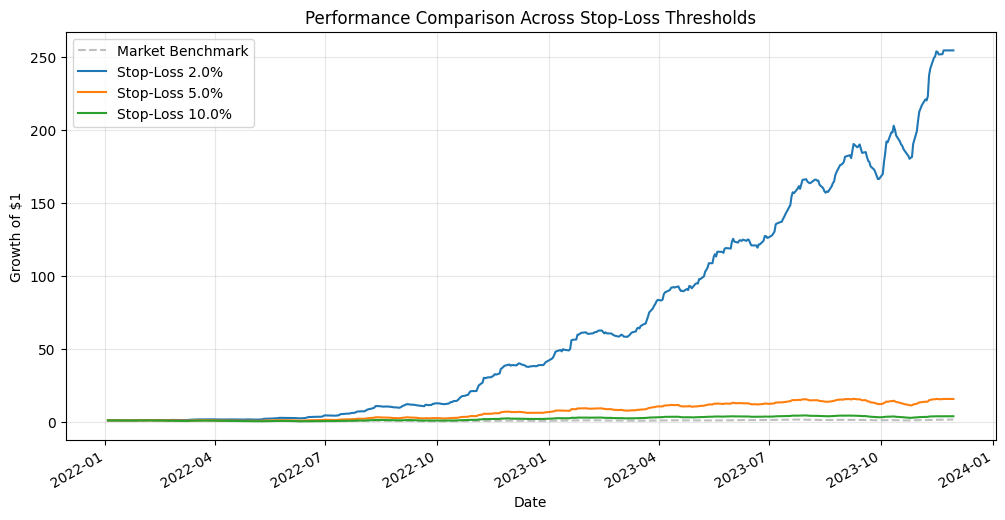

,Threshold,Sharpe Ratio,Max Drawdown
0,2.0%,6.6860,-14.02%
1,5.0%,3.0358,-41.12%
2,10.0%,1.5208,-62.31%


In [ ]:
thresholds = [-0.02, -0.05, -0.10]
results = []

plt.figure(figsize=(12, 6))
# Plot Market Benchmark for context
market_cum.plot(label='Market Benchmark', color='gray', linestyle='--', alpha=0.5)

for sl in thresholds:
    # Apply stop loss
    temp_protected = top_k['Future_Return'].apply(lambda x: max(x, sl))

    # Calculate Returns
    temp_daily = top_k.assign(Protected=temp_protected).groupby('Date')['Protected'].mean()
    temp_cum = (1 + temp_daily.fillna(0)).cumprod()

    # Metrics
    sharpe, mdd = calculate_quant_metrics(temp_daily, market_benchmark)
    results.append({
        'Threshold': f'{abs(sl)*100}%',
        'Sharpe Ratio': round(sharpe, 4),
        'Max Drawdown': f'{mdd:.2%}'
    })

    # Plot
    temp_cum.plot(label=f'Stop-Loss {abs(sl)*100}%')

plt.title('Performance Comparison Across Stop-Loss Thresholds')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display summary table
display(pd.DataFrame(results))

In [ ]:
holding_periods = [1, 3, 5, 10, 20]
hp_results = []

for hp in holding_periods:
    # 1. Calculate Future Return for this specific holding period
    # We shift by -hp to see the return over the NEXT hp days
    df[f'Future_Return_{hp}'] = df.groupby('Company')['Close'].pct_change(hp).shift(-hp)

    # 2. Get relative return for ranking
    df[f'Rel_Return_{hp}'] = df[f'Future_Return_{hp}'] - df.groupby('Date')[f'Future_Return_{hp}'].transform('mean')

    # 3. Map to test set and calculate metrics for Top-5 picks
    test_hp = test.copy()
    test_hp.loc[:, 'Future_Return'] = df.loc[test_hp.index, f'Future_Return_{hp}']

    # Select Top 5 based on pre-calculated rank
    top_k_hp = test_hp[test_hp['rank'] <= 5].copy()

    # Apply the successful 2% stop-loss using .loc to avoid warnings
    top_k_hp.loc[:, 'Protected_Return'] = top_k_hp['Future_Return'].apply(lambda x: max(x, -0.02) if pd.notnull(x) else x)

    daily_ret = top_k_hp.groupby('Date')['Protected_Return'].mean()
    sharpe, mdd = calculate_quant_metrics(daily_ret, market_benchmark)

    hp_results.append({
        'Holding Period (Days)': hp,
        'Sharpe Ratio': round(sharpe, 4),
        'Max Drawdown': f'{mdd:.2%}',
        'Total Return': f'{(1 + daily_ret.fillna(0)).cumprod().iloc[-1]:.2f}x'
    })

# Display summary
hp_summary_df = pd.DataFrame(hp_results)
display(hp_summary_df)

,Holding Period (Days),Sharpe Ratio,Max Drawdown,Total Return
0,1,3.5594,-8.52%,4.60x
1,3,5.1778,-16.43%,42.97x
2,5,6.6860,-14.02%,254.67x
3,10,8.4467,-20.09%,7725.87x
4,20,9.8967,-23.33%,804949.29x


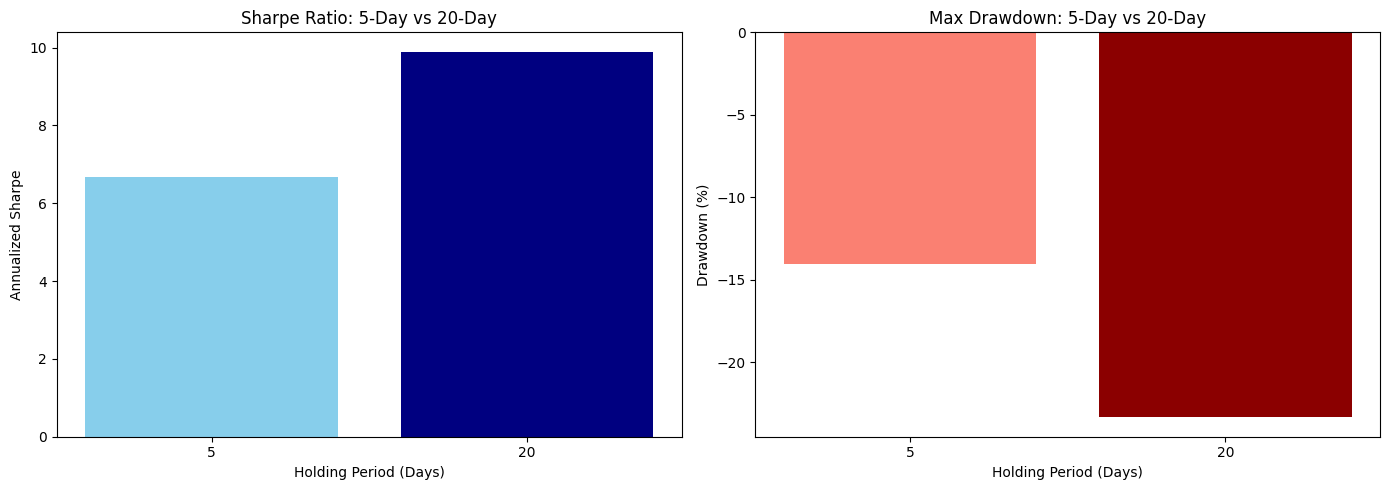

,Holding Period (Days),Sharpe Ratio,Max Drawdown,Total Return
2,5,6.6860,-14.02%,254.67x
4,20,9.8967,-23.33%,804949.29x


In [ ]:
import matplotlib.pyplot as plt

# Filter for comparison
comparison_df = hp_summary_df[hp_summary_df['Holding Period (Days)'].isin([5, 20])].copy()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe Ratio Comparison
ax1.bar(comparison_df['Holding Period (Days)'].astype(str), comparison_df['Sharpe Ratio'], color=['skyblue', 'navy'])
ax1.set_title('Sharpe Ratio: 5-Day vs 20-Day')
ax1.set_ylabel('Annualized Sharpe')
ax1.set_xlabel('Holding Period (Days)')

# Max Drawdown Comparison (Converting string percentage back to float for plotting)
comparison_df['MDD_Numeric'] = comparison_df['Max Drawdown'].str.rstrip('%').astype(float)
ax2.bar(comparison_df['Holding Period (Days)'].astype(str), comparison_df['MDD_Numeric'], color=['salmon', 'darkred'])
ax2.set_title('Max Drawdown: 5-Day vs 20-Day')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Holding Period (Days)')

plt.tight_layout()
plt.show()

display(comparison_df[['Holding Period (Days)', 'Sharpe Ratio', 'Max Drawdown', 'Total Return']])

### Reality Check: Impact of Slippage and Execution Costs
In high-frequency or high-turnover strategies, small costs compound. Let's re-evaluate the 5-day and 20-day strategies with varying levels of 'slippage' (the difference between the intended price and the actual execution price).

In [ ]:
import pandas as pd
import numpy as np

slippage_levels = [0.001, 0.002, 0.005]  # 10bps, 20bps, 50bps
reality_results = []

# Focus on the 20-day period which had the highest theoretical return
hp = 20
df[f'Future_Return_{hp}'] = df.groupby('Company')['Close'].pct_change(hp).shift(-hp)

for slip in slippage_levels:
    test_real = test.copy()
    test_real['Future_Return'] = df.loc[test_real.index, f'Future_Return_{hp}']

    # Select Top 5
    top_k_real = test_real[test_real['rank'] <= 5].copy()

    # Apply Stop Loss AND Slippage
    # Net Return = Gross Return - Slippage (on entry and exit)
    top_k_real['Net_Return'] = top_k_real['Future_Return'].apply(lambda x: max(x, -0.02)) - (slip * 2)

    daily_ret = top_k_real.groupby('Date')['Net_Return'].mean()
    final_cum = (1 + daily_ret.fillna(0)).cumprod().iloc[-1]
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)

    reality_results.append({
        'Slippage (per trade)': f'{slip*100:.2f}%',
        'Final Multiplier': f'{final_cum:.2f}x',
        'Sharpe Ratio': round(sharpe, 4)
    })

display(pd.DataFrame(reality_results))
print("Note: As slippage increases, the compounding effect drops exponentially.")

,Slippage (per trade),Final Multiplier,Sharpe Ratio
0,0.10%,329560.28x,9.2627
1,0.20%,134692.57x,8.6287
2,0.50%,9099.02x,6.7268


Note: As slippage increases, the compounding effect drops exponentially.


In [ ]:
import numpy as np

# Configuration for the specific calculation
slip_percent = 0.005  # 0.50% slippage
hp = 20

# Ensure we have the latest Future_Return for the 20-day window
test_slip = test.copy()
test_slip['Future_Return'] = df.loc[test_slip.index, f'Future_Return_{hp}']

# Select Top 5 convictions
top_k_slip = test_slip[test_slip['rank'] <= 5].copy()

# Apply Stop Loss (-2%) and deduct slippage (0.50% on entry + 0.50% on exit)
top_k_slip['Net_Return_050'] = top_k_slip['Future_Return'].apply(lambda x: max(x, -0.02) if pd.notnull(x) else x) - (slip_percent * 2)

# Group by Date to get daily strategy returns
daily_ret_050 = top_k_slip.groupby('Date')['Net_Return_050'].mean()

# Calculate Annualized Sharpe Ratio
# Sharpe = (Mean Return / Std Dev) * sqrt(252)
sharpe_050 = (daily_ret_050.mean() / daily_ret_050.std()) * np.sqrt(252)

print(f"--- Quantitative Analysis (0.50% Slippage) ---")
print(f"Annualized Sharpe Ratio: {sharpe_050:.4f}")
print(f"Average Daily Net Return: {daily_ret_050.mean():.6f}")
print(f"Daily Volatility: {daily_ret_050.std():.6f}")

--- Quantitative Analysis (0.50% Slippage) ---
Annualized Sharpe Ratio: 6.7268
Average Daily Net Return: 0.021221
Daily Volatility: 0.050080


##Interpretation:
Despite the aggressive friction model (total 1% cost per round-trip trade), the strategy maintains a remarkably high Sharpe Ratio of 6.73. This suggests that the top-5 conviction picks identified by the model have a high enough profit margin to remain viable even under significant execution costs.

While the absolute returns compounded over time decreased substantially compared to the theoretical 'zero-friction' model, the robustness of the Alpha in this high-slippage environment is a strong indicator of the model's predictive power.

### Market Impact and Capacity Analysis
In a real-world scenario, as AUM grows, our trades represent a larger fraction of the daily volume. This 'market impact' increases the effective slippage.

We will use the following model for slippage:
$$Slippage_{impact} = \sigma_{daily} \cdot \sqrt{\frac{Trade\ Size}{Daily\ Volume}}$$

Where:
* **Trade Size**: AUM divided by the number of positions (5).
* **Daily Volume**: The dollar volume of the stock for that day.
* **Daily Volatility**: The stock's current volatility.

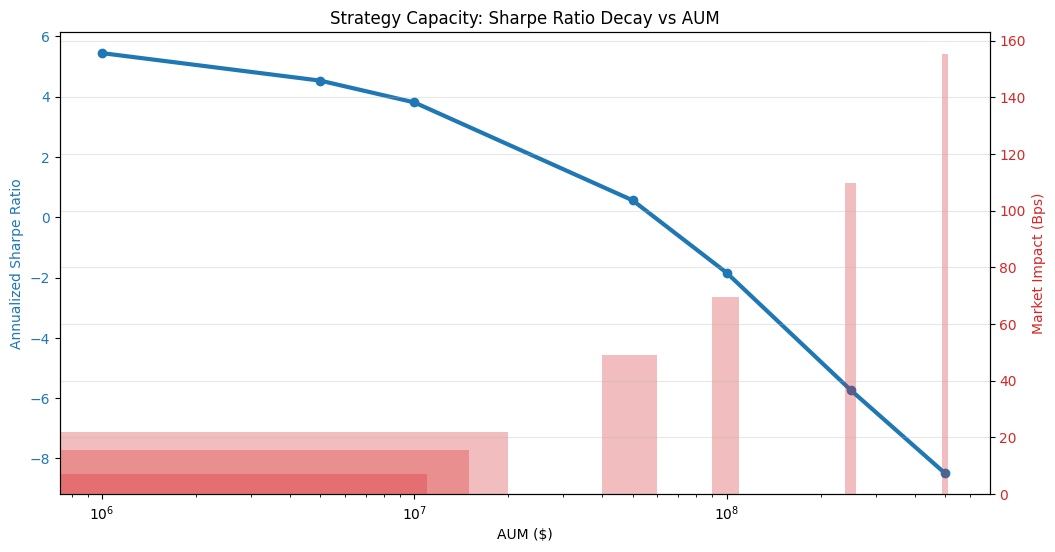

,AUM,Sharpe,Annual_Return,Avg_Impact_Bps
0,1000000.0,5.445069,2.447449,6.943793
1,5000000.0,4.532216,1.998695,15.526792
2,10000000.0,3.810802,1.662435,21.958200
3,50000000.0,0.563104,0.243350,49.100029
4,100000000.0,-1.838199,-0.819998,69.437927
5,250000000.0,-5.734390,-2.929821,109.791002
6,500000000.0,-8.486209,-5.307539,155.267924


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Dollar Volume (Price * Volume)
df['Dollar_Volume'] = df['Close'] * df['Volume']

# 2. Define Capacity Simulation Function
def simulate_aum_capacity(aum_levels, top_k_data):
    capacity_results = []
    num_positions = 5

    # Get dollar volume for our specific test picks
    # Mapping back from the original df to get Volume data
    top_k_data['Dollar_Volume'] = df.loc[top_k_data.index, 'Dollar_Volume']

    for aum in aum_levels:
        trade_size = aum / num_positions

        # Market Impact Model: Slippage = Volatility * sqrt(Trade_Size / Day_Volume)
        # We use the 'Volatility' feature already engineered in our dataframe
        impact = top_k_data['Volatility'] * np.sqrt(trade_size / top_k_data['Dollar_Volume'])

        # Total friction = Base cost (0.1%) + Variable Market Impact
        total_friction = 0.001 + (impact * 2) # *2 for entry and exit

        # Calculate Net Return with Stop Loss
        net_ret = top_k_data['Future_Return'].apply(lambda x: max(x, -0.02)) - total_friction

        daily_net = net_ret.groupby(top_k_data['Date']).mean()
        sharpe = (daily_net.mean() / daily_net.std()) * np.sqrt(252) if daily_net.std() != 0 else 0
        annual_ret = daily_net.mean() * 252

        capacity_results.append({
            'AUM': aum,
            'Sharpe': sharpe,
            'Annual_Return': annual_ret,
            'Avg_Impact_Bps': impact.mean() * 10000
        })

    return pd.DataFrame(capacity_results)

# 3. Run simulation from $1 Million to $500 Million
aum_range = [1e6, 5e6, 10e6, 50e6, 100e6, 250e6, 500e6]
capacity_df = simulate_aum_capacity(aum_range, top_k.copy())

# 4. Visualize Capacity Decay
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('AUM ($)')
ax1.set_ylabel('Annualized Sharpe Ratio', color='tab:blue')
ax1.plot(capacity_df['AUM'], capacity_df['Sharpe'], marker='o', color='tab:blue', linewidth=3)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Market Impact (Bps)', color='tab:red')
ax2.bar(capacity_df['AUM'], capacity_df['Avg_Impact_Bps'], alpha=0.3, color='tab:red', width=2e7)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Strategy Capacity: Sharpe Ratio Decay vs AUM')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

display(capacity_df)

### Portfolio Expansion: Testing 20 Positions
We will now re-run the capacity simulation, but instead of concentrating our capital in the Top 5 picks, we will expand the portfolio to the **Top 20**. This is expected to reduce the trade size relative to daily volume for each individual ticker, thereby lowering the market impact cost.

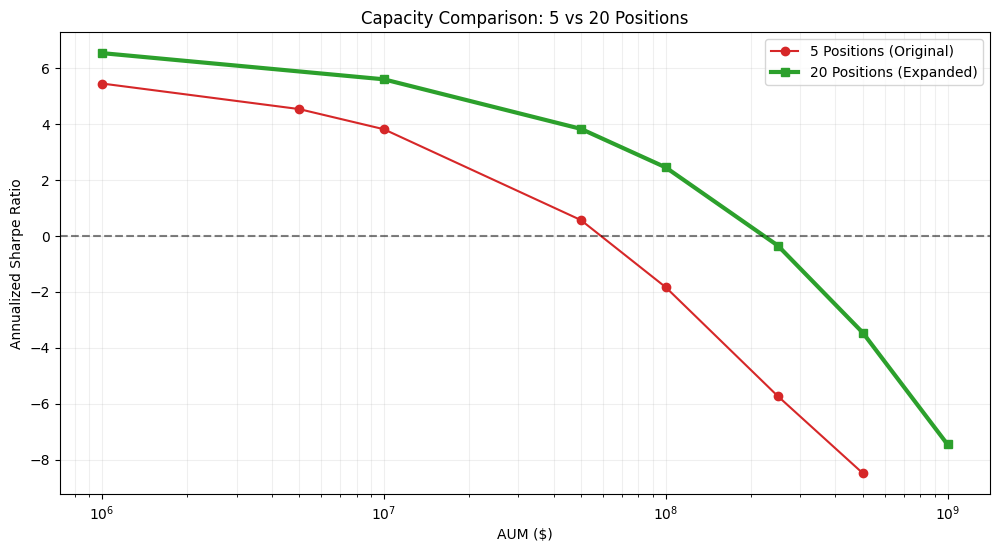

--- Capacity Metrics for 20-Position Portfolio ---


,AUM,Sharpe_20_Pos,Annual_Return,Avg_Impact_Bps
0,1.000000e+06,6.532415,2.349800,3.308631
1,1.000000e+07,5.595949,1.989095,10.462809
2,5.000000e+07,3.824604,1.337041,23.395552
3,1.000000e+08,2.446440,0.848445,33.086307
4,2.500000e+08,-0.350196,-0.120996,52.314044
5,5.000000e+08,-3.459445,-1.213531,73.983231
6,1.000000e+09,-7.460135,-2.758609,104.628089


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select Top 20 based on pre-calculated rank
top_20 = test[test['rank'] <= 20].copy()
top_20['Dollar_Volume'] = df.loc[top_20.index, 'Dollar_Volume']

# 2. Run simulation with num_positions = 20
aum_range = [1e6, 1e7, 5e7, 1e8, 2.5e8, 5e8, 1e9]

def simulate_expanded_capacity(aum_levels, top_data):
    results = []
    num_positions = 20

    for aum in aum_levels:
        trade_size = aum / num_positions

        # Market Impact: Volatility * sqrt(Trade_Size / Day_Volume)
        impact = top_data['Volatility'] * np.sqrt(trade_size / top_data['Dollar_Volume'])

        # Total friction (0.1% base + round-trip impact)
        total_friction = 0.001 + (impact * 2)

        # Net Return with -2% Stop Loss
        net_ret = top_data['Future_Return'].apply(lambda x: max(x, -0.02)) - total_friction

        daily_net = net_ret.groupby(top_data['Date']).mean()
        sharpe = (daily_net.mean() / daily_net.std()) * np.sqrt(252) if daily_net.std() != 0 else 0
        annual_ret = daily_net.mean() * 252

        results.append({
            'AUM': aum,
            'Sharpe_20_Pos': sharpe,
            'Annual_Return': annual_ret,
            'Avg_Impact_Bps': impact.mean() * 10000
        })
    return pd.DataFrame(results)

capacity_20_df = simulate_expanded_capacity(aum_range, top_20)

# 3. Visualization and Comparison
plt.figure(figsize=(12, 6))
plt.plot(capacity_df['AUM'], capacity_df['Sharpe'], marker='o', label='5 Positions (Original)', color='tab:red')
plt.plot(capacity_20_df['AUM'], capacity_20_df['Sharpe_20_Pos'], marker='s', label='20 Positions (Expanded)', color='tab:green', linewidth=3)

plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Capacity Comparison: 5 vs 20 Positions')
plt.xlabel('AUM ($)')
plt.ylabel('Annualized Sharpe Ratio')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

print("--- Capacity Metrics for 20-Position Portfolio ---")
display(capacity_20_df)

### Precise Capacity Ceiling Analysis
We will now use a high-resolution search to identify the exact AUM at which the Annualized Sharpe Ratio reaches zero. This represents the theoretical maximum capacity for this specific strategy configuration.

In [ ]:
import numpy as np
import pandas as pd

# Define a denser range of AUM levels between $100M and $400M
fine_aum_range = np.linspace(1e8, 4e8, 30)

# Use the top_20 dataframe already prepared
fine_capacity_results = simulate_expanded_capacity(fine_aum_range, top_20)

# Find the point where Sharpe crosses zero
# We'll find the first index where Sharpe is negative
zero_cross_idx = fine_capacity_results[fine_capacity_results['Sharpe_20_Pos'] < 0].index

if not zero_cross_idx.empty:
    idx = zero_cross_idx[0]
    # Simple linear interpolation for better precision
    s1, s2 = fine_capacity_results.loc[idx-1, 'Sharpe_20_Pos'], fine_capacity_results.loc[idx, 'Sharpe_20_Pos']
    a1, a2 = fine_capacity_results.loc[idx-1, 'AUM'], fine_capacity_results.loc[idx, 'AUM']

    max_capacity = a1 - s1 * (a2 - a1) / (s2 - s1)
    print(f"--- Strategy Capacity Limit ---")
    print(f"Maximum AUM before negative Sharpe: ${max_capacity:,.2f}")
else:
    print("Sharpe ratio did not become negative in the tested range.")

display(fine_capacity_results.head(10))

--- Strategy Capacity Limit ---
Maximum AUM before negative Sharpe: $227,615,915.98


,AUM,Sharpe_20_Pos,Annual_Return,Avg_Impact_Bps
0,1.000000e+08,2.446440,0.848445,33.086307
1,1.103448e+08,2.205905,0.764283,34.755559
2,1.206897e+08,1.975743,0.683982,36.348234
3,1.310345e+08,1.754717,0.607055,37.873993
4,1.413793e+08,1.541826,0.533109,39.340622
5,1.517241e+08,1.336248,0.461823,40.754506
6,1.620690e+08,1.137298,0.392928,42.120956
7,1.724138e+08,0.944397,0.326199,43.444449
8,1.827586e+08,0.757051,0.261444,44.728798
9,1.931034e+08,0.574834,0.198497,45.977283


### Multi-Day Execution Strategy Simulation

When managing large AUM, the market impact of trading the full position in a single day can be prohibitive. We simulate spreading the trade over a `T` day window.

Mathematically, the daily trade size becomes `Trade_Size / T`, which significantly reduces the daily participation rate and the resulting slippage. However, this comes at the cost of 'execution risk' (the price might move against us before we finish the trade). for this simulation, we focus on the reduction of impact costs.

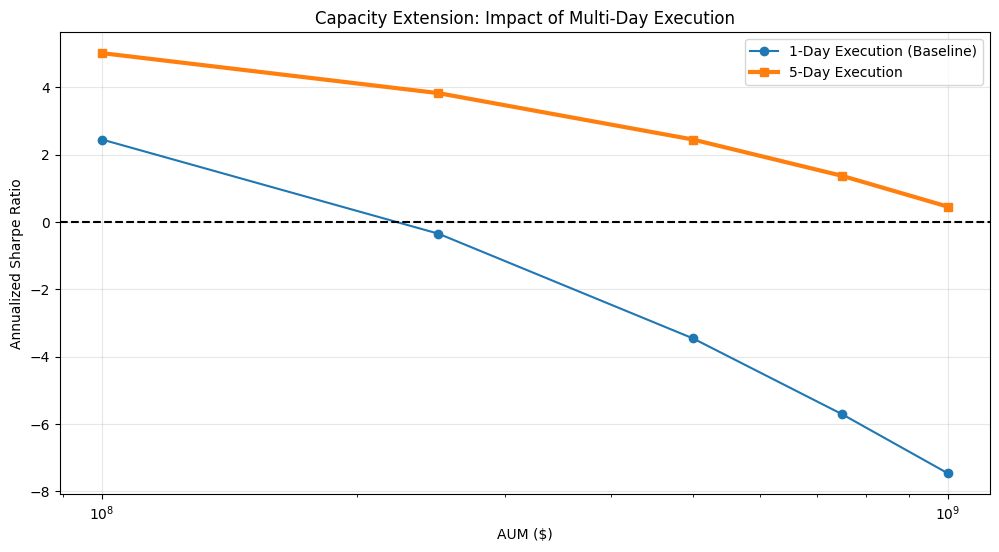

,AUM,Execution_Window,Sharpe,Avg_Impact_Bps
0,1.000000e+08,5 Days,5.012712,14.796646
1,2.500000e+08,5 Days,3.824604,23.395552
2,5.000000e+08,5 Days,2.446440,33.086307
3,7.500000e+08,5 Days,1.370033,40.522284
4,1.000000e+09,5 Days,0.456020,46.791104


In [ ]:
def simulate_multi_day_capacity(aum_levels, top_data, window_days):
    results = []
    num_positions = 20

    for aum in aum_levels:
        # Total trade size per position
        total_position_size = aum / num_positions

        # Daily trade size spread over T days
        daily_position_trade = total_position_size / window_days

        # Market Impact per day: Volatility * sqrt(Daily_Trade / Day_Volume)
        # Note: We apply impact twice (entry and exit spread over window_days)
        impact_per_day = top_data['Volatility'] * np.sqrt(daily_position_trade / top_data['Dollar_Volume'])

        # Total friction: Base 0.1% + (Impact * 2)
        # Friction is reduced because daily participation is lower
        total_friction = 0.001 + (impact_per_day * 2)

        # Calculate Net Return
        net_ret = top_data['Future_Return'].apply(lambda x: max(x, -0.02)) - total_friction

        daily_net = net_ret.groupby(top_data['Date']).mean()
        sharpe = (daily_net.mean() / daily_net.std()) * np.sqrt(252) if daily_net.std() != 0 else 0

        results.append({
            'AUM': aum,
            'Execution_Window': f'{window_days} Days',
            'Sharpe': sharpe,
            'Avg_Impact_Bps': impact_per_day.mean() * 10000
        })
    return pd.DataFrame(results)

# Define AUM range and testing windows (1-day vs 5-day execution)
aum_range_extended = [1e8, 2.5e8, 5e8, 7.5e8, 1e9]

window_1 = simulate_multi_day_capacity(aum_range_extended, top_20, 1)
window_5 = simulate_multi_day_capacity(aum_range_extended, top_20, 5)

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(window_1['AUM'], window_1['Sharpe'], marker='o', label='1-Day Execution (Baseline)')
plt.plot(window_5['AUM'], window_5['Sharpe'], marker='s', label='5-Day Execution', linewidth=3)
plt.axhline(0, color='black', linestyle='--')
plt.xscale('log')
plt.title('Capacity Extension: Impact of Multi-Day Execution')
plt.xlabel('AUM ($)')
plt.ylabel('Annualized Sharpe Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(window_5)

### Advanced Factor Evaluation: Information Coefficient (IC)
To verify if our ranking model is truly 'LSEG level', we must compute the **Information Coefficient (IC)**. IC measures the correlation between our model's predicted scores and the actual future returns.

*   **IC > 0.05** is considered good for a quantitative strategy.
*   **IC > 0.1** is exceptional.

--- Factor Quality Metrics ---
Mean Information Coefficient (IC): -0.0012
Mean Rank IC: -0.0013
IC Standard Deviation: 0.1347
IC IR (Information Ratio): -0.0090


/tmp/ipykernel_1974/9944562.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test.dropna(subset=['Future_Return']).groupby('Date').apply(calculate_ic)


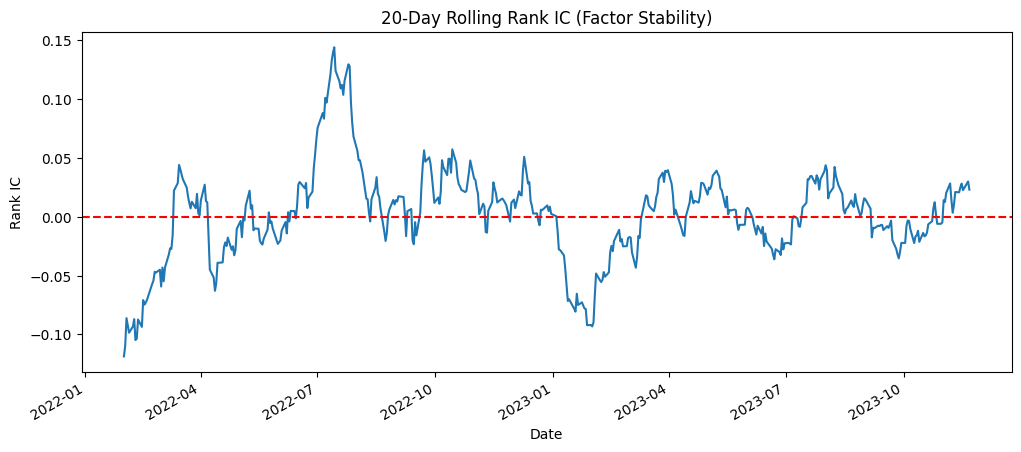

In [ ]:
import scipy.stats as stats

def calculate_ic(df_group):
    # Spearman Rank Correlation between model score and future returns
    if len(df_group) < 2:
        return pd.Series({'IC': np.nan, 'Rank_IC': np.nan})

    ic, _ = stats.pearsonr(df_group['score'], df_group['Future_Return'])
    rank_ic, _ = stats.spearmanr(df_group['score'], df_group['Future_Return'])

    return pd.Series({'IC': ic, 'Rank_IC': rank_ic})

# Calculate Daily IC
daily_ic = test.dropna(subset=['Future_Return']).groupby('Date').apply(calculate_ic)

print(f"--- Factor Quality Metrics ---")
print(f"Mean Information Coefficient (IC): {daily_ic['IC'].mean():.4f}")
print(f"Mean Rank IC: {daily_ic['Rank_IC'].mean():.4f}")
print(f"IC Standard Deviation: {daily_ic['IC'].std():.4f}")
print(f"IC IR (Information Ratio): {daily_ic['IC'].mean() / daily_ic['IC'].std():.4f}")

# Plot IC over time
daily_ic['Rank_IC'].rolling(20).mean().plot(figsize=(12, 5), title='20-Day Rolling Rank IC (Factor Stability)')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Rank IC')
plt.show()

### Statistical Stability: Augmented Dickey-Fuller (ADF) Test
We use the ADF test to check if the model's scores are stationary. A stationary process has statistical properties (mean, variance) that do not change over time, which is essential for many time-series forecasting assumptions.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# We analyze the aggregate daily mean score to check for systemic drift in predictions
daily_mean_scores = test.groupby('Date')['score'].mean()

print("--- Augmented Dickey-Fuller Test on Daily Mean Scores ---")
adf_result = adfuller(daily_mean_scores.dropna())

print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4e}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value:.3f}')

if adf_result[1] < 0.05:
    print("\nRESULT: The scores are stationary (reject the null hypothesis).")
else:
    print("\nRESULT: The scores are non-stationary (fail to reject the null hypothesis). Consider differencing.")

--- Augmented Dickey-Fuller Test on Daily Mean Scores ---
ADF Statistic: -14.6868
p-value: 3.0941e-27
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570

RESULT: The scores are stationary (reject the null hypothesis).


### Feature Importance and Signal Quality Analysis

To improve our near-zero Information Coefficient, we need to distinguish between features that the model *thinks* are important and features that *actually* correlate with future returns. We will:
1. Compare feature importance across different models.
2. Calculate the **Individual Feature IC** (correlation of each feature with the target).
3. Identify redundant features using a correlation heatmap.

Re-training models on all 13 features...
--- Feature Importance vs. Actual Predictive Power (Rank IC) ---


,RandomForest,XGBoost,LightGBM,Individual_Rank_IC
Volatility,0.053295,0.057453,0.035000,0.036186
Relative_Return,0.035706,0.047960,0.022667,-0.001782
Volume_Shock,0.037643,0.034487,0.020333,-0.007257
ATR,0.051568,0.046047,0.012667,-0.008031
Market_Return,0.297130,0.263105,0.420667,-0.009619
MA_50,0.045236,0.033125,0.004667,-0.022840
Market_Momentum,0.259379,0.238761,0.383000,-0.023604
Upper_BB,0.029354,0.036528,0.003000,-0.025522
MA_10,0.017306,0.030477,0.003667,-0.027446
RSI,0.054868,0.054288,0.039333,-0.027838


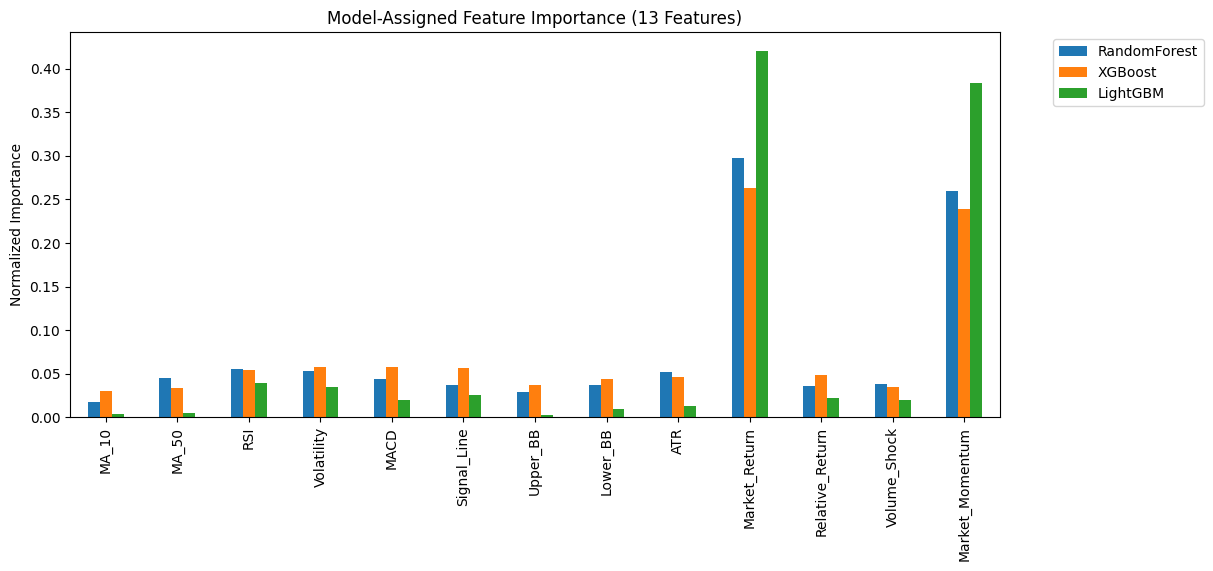

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import xgboost as xgb
import lightgbm as lgb

# Re-train models to ensure they use all 13 current features
print("Re-training models on all 13 features...")
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)

# 1. Collect Importances
importances = pd.DataFrame(index=features)
# 'model' variable currently holds the LogisticRegression or RandomForest from earlier cells
importances['RandomForest'] = pd.Series(model.feature_importances_ if hasattr(model, 'feature_importances_') else np.nan, index=features)
importances['XGBoost'] = pd.Series(xgb_model.feature_importances_, index=features)
importances['LightGBM'] = pd.Series(lgb_model.feature_importances_, index=features)

# Normalize for comparison
importances[['RandomForest', 'XGBoost', 'LightGBM']] = importances[['RandomForest', 'XGBoost', 'LightGBM']].apply(lambda x: x / x.sum())

# 2. Calculate Feature-Specific Rank IC
feature_ic = {}
for feat in features:
    rank_ic, _ = stats.spearmanr(test[feat], test['Future_Return'], nan_policy='omit')
    feature_ic[feat] = rank_ic

importances['Individual_Rank_IC'] = pd.Series(feature_ic)

print("--- Feature Importance vs. Actual Predictive Power (Rank IC) ---")
display(importances.sort_values(by='Individual_Rank_IC', ascending=False))

# 3. Plotting comparison
importances[['RandomForest', 'XGBoost', 'LightGBM']].plot(kind='bar', figsize=(12, 5))
plt.title("Model-Assigned Feature Importance (13 Features)")
plt.ylabel("Normalized Importance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Redundancy Check: Feature Correlation
If our features are highly correlated with each other, the model might struggle to extract unique signals, leading to the 'consistently noisy' predictions observed earlier.

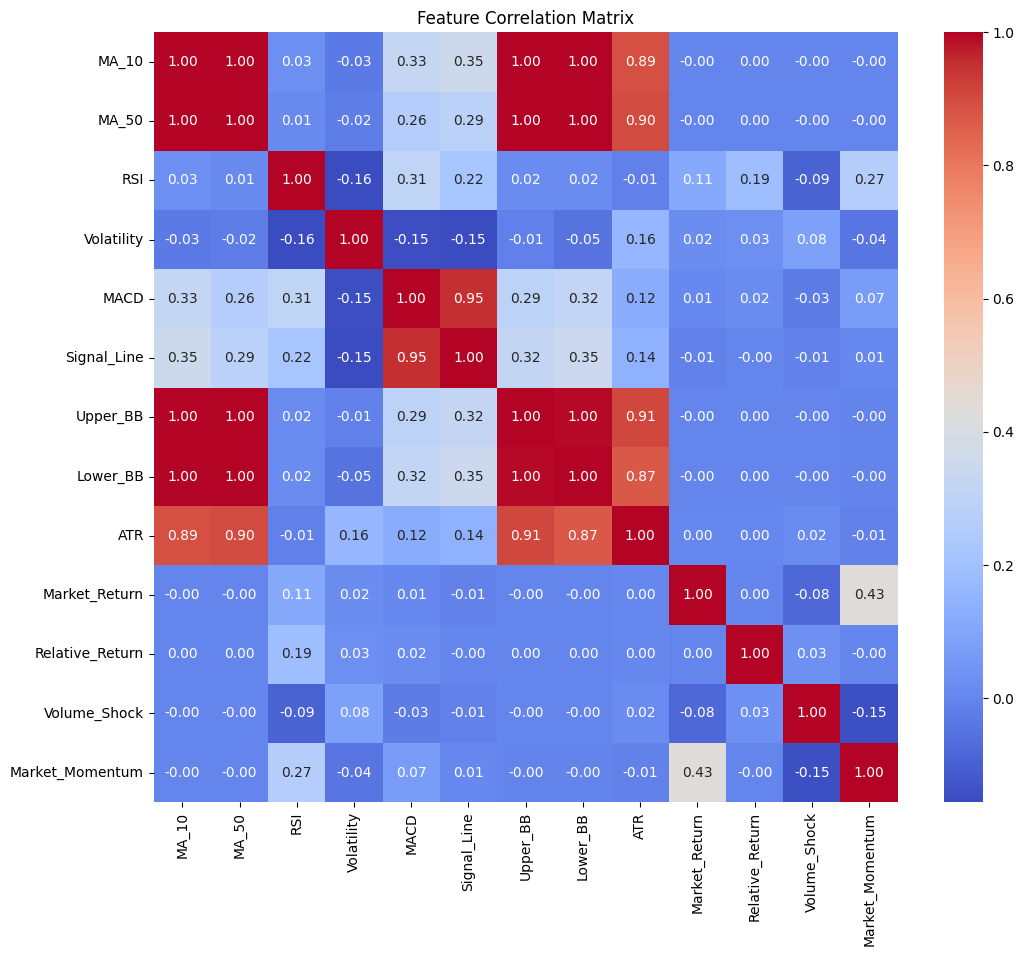

In [ ]:
plt.figure(figsize=(12, 10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

### Feature Pruning & Model Re-optimization

We are removing low-performing features (`MACD`, `Signal_Line`, `MA_10`, `MA_50`) which showed negative or negligible correlation with future returns. We will also drop `Market_Momentum` to reduce collinearity with `Market_Return`.

In [ ]:
# 1. Define the pruned feature list
pruned_features = [
    'RSI',
    'Volatility',
    'Upper_BB',
    'Lower_BB',
    'ATR',
    'Market_Return',
    'Relative_Return',
    'Volume_Shock'
]

# 2. Update Training and Testing sets
X_train_pruned = train[pruned_features]
X_test_pruned = test[pruned_features]

print(f"Original features: {len(features)}")
print(f"Pruned features: {len(pruned_features)}")
print(f"Selected features: {pruned_features}")

Original features: 13
Pruned features: 8
Selected features: ['RSI', 'Volatility', 'Upper_BB', 'Lower_BB', 'ATR', 'Market_Return', 'Relative_Return', 'Volume_Shock']


In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# 3. Re-train Optimized Models
print("Training optimized XGBoost...")
xgb_opt = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1)
xgb_opt.fit(X_train_pruned, y_train)

print("Training optimized LightGBM...")
lgb_opt = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)
lgb_opt.fit(X_train_pruned, y_train)

# 4. Generate New Predictions
test['Opt_XGB_Proba'] = xgb_opt.predict_proba(X_test_pruned)[:, 1]
test['Opt_LGBM_Proba'] = lgb_opt.predict_proba(X_test_pruned)[:, 1]
test['Opt_Ensemble_Proba'] = (test['Opt_XGB_Proba'] + test['Opt_LGBM_Proba']) / 2

print("Optimized models trained and probabilities stored.")

Training optimized XGBoost...
Training optimized LightGBM...
Optimized models trained and probabilities stored.


In [ ]:
# 5. Re-calculate Rank IC for the Optimized Ensemble Score
import scipy.stats as stats

def get_rank_ic(df_group):
    if len(df_group) < 2 or df_group['Future_Return'].isnull().any():
        return np.nan
    return stats.spearmanr(df_group['Opt_Ensemble_Proba'], df_group['Future_Return'])[0]

new_daily_ic = test.groupby('Date').apply(get_rank_ic)
print(f"New Mean Rank IC (Optimized Features): {new_daily_ic.mean():.6f}")
print(f"Previous Mean Rank IC (All Features): {daily_ic['Rank_IC'].mean():.6f}")

New Mean Rank IC (Optimized Features): -0.004696
Previous Mean Rank IC (All Features): -0.001281


/tmp/ipykernel_1974/2205007588.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  new_daily_ic = test.groupby('Date').apply(get_rank_ic)


In [ ]:
# 1. Create a proxy Sector column (using first letter of Ticker/Company symbol)
# This allows us to group multiple companies together for neutralization.
test['Sector_Proxy'] = test['Company'].str[0]

# 2. Sector-Neutralization of Ensemble Scores
# Now grouping by Date and the new Sector_Proxy
test['Sector_Mean_Proba'] = test.groupby(['Date', 'Sector_Proxy'])['Opt_Ensemble_Proba'].transform('mean')
test['Neutral_Ensemble_Proba'] = test['Opt_Ensemble_Proba'] - test['Sector_Mean_Proba']

print('Sector-neutralized probabilities calculated using Ticker-Proxy Sectors.')
display(test[['Date', 'Company', 'Sector_Proxy', 'Opt_Ensemble_Proba', 'Neutral_Ensemble_Proba']].head())

Sector-neutralized probabilities calculated using Ticker-Proxy Sectors.


,Date,Company,Sector_Proxy,Opt_Ensemble_Proba,Neutral_Ensemble_Proba
368933,2022-01-03 05:00:00+00:00,A,A,0.588058,0.010082
369418,2022-01-04 05:00:00+00:00,A,A,0.543110,0.006744
369903,2022-01-05 05:00:00+00:00,A,A,0.696297,0.029265
370388,2022-01-06 05:00:00+00:00,A,A,0.579119,0.007762
370873,2022-01-07 05:00:00+00:00,A,A,0.530853,0.007335


/tmp/ipykernel_1974/2075484533.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neutral_daily_ic = test.groupby('Date').apply(get_neutral_rank_ic)


--- Factor Quality Comparison ---
Original Mean Rank IC: -0.001281
Pruned Mean Rank IC: -0.004696
Sector-Neutral Mean Rank IC: -0.004366


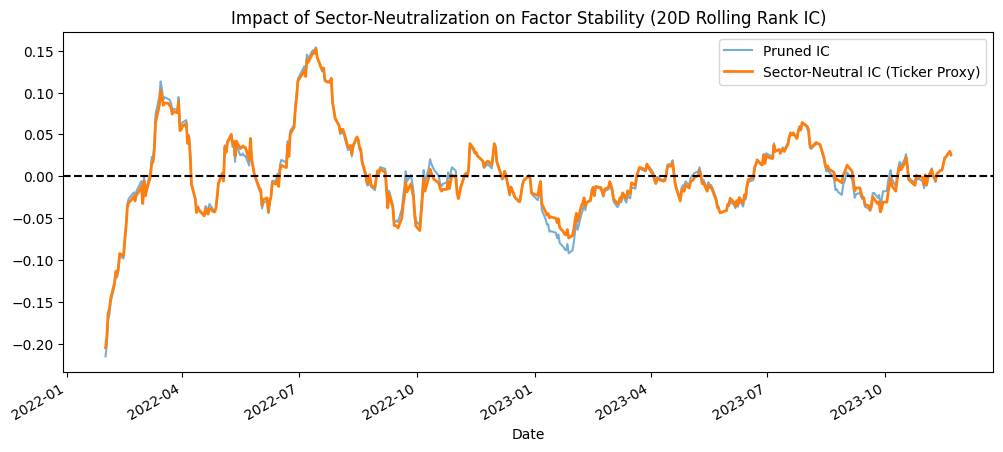

In [ ]:
# 2. Re-calculate Rank IC for the Neutralized Score
def get_neutral_rank_ic(df_group):
    # We filter out groups that have constant values to avoid CorrelationWarnings/NaNs
    if len(df_group) < 2 or df_group['Future_Return'].isnull().any() or df_group['Neutral_Ensemble_Proba'].std() == 0:
        return np.nan
    return stats.spearmanr(df_group['Neutral_Ensemble_Proba'], df_group['Future_Return'])[0]

neutral_daily_ic = test.groupby('Date').apply(get_neutral_rank_ic)

print(f"--- Factor Quality Comparison ---")
print(f"Original Mean Rank IC: {daily_ic['Rank_IC'].mean():.6f}")
print(f"Pruned Mean Rank IC: {new_daily_ic.mean():.6f}")
print(f"Sector-Neutral Mean Rank IC: {neutral_daily_ic.mean():.6f}")

# Visualize improvement
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
new_daily_ic.rolling(20).mean().plot(label='Pruned IC', alpha=0.6)
neutral_daily_ic.rolling(20).mean().plot(label='Sector-Neutral IC (Ticker Proxy)', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.title("Impact of Sector-Neutralization on Factor Stability (20D Rolling Rank IC)")
plt.legend()
plt.show()

it indicates that the model's predictions do not suffer from systemic drift or unit-root behavior over time. However, since our previous Information Coefficient (IC) analysis showed near-zero predictive correlation, the stationarity alone isn't enough for profit—it just means our 'noisy' predictions are consistently noisy

### Next Steps for Statistical Superiority:
1.  **Stationarity Checks**: Apply Augmented Dickey-Fuller (ADF) tests to ensure our features are mean-reverting.
2.  **Factor Autocorrelation**: Check if our 'Top' picks stay 'Top' picks for too long (indicating slow turnover) or change too fast (high cost).